# Sistema Multi-Robot — Notebook Jupyter/Colab

Este notebook une los códigos del proyecto en una sola versión ejecutable por secciones:

1. Modelos cinemáticos de robots: `PuzzleBot`, `HuskyA200` y `ANYmal`.
2. `Watcher` para detectar eventos del corredor.
3. Fase Husky: limpieza del corredor.
4. Fase ANYmal: transporte.
5. Fase PuzzleBots: apilado cooperativo.
6. Coordinador FSM de misión completa.
7. Gráficas y animación integrada.

> Ejecuta las celdas en orden. En Colab no necesitas archivos `.py` externos porque todo está integrado aquí.


In [ ]:
# Notebook setup
import numpy as np
import matplotlib.pyplot as plt

try:
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML, display
except Exception:
    FuncAnimation = None

%matplotlib inline


## 1. Modelos base de robots

Incluye las clases base de `robots.py`: PuzzleBot diferencial, Husky A200 y ANYmal.


######################################################################
#   ROBOTS MOVILES TERRESTRES - Ejecutando todos los demos
######################################################################

DEMO PuzzleBot

[1] Avanzar en linea recta (wR = wL = 10 rad/s)
    Pose final: x=1.500, y=0.000, theta=0.0 deg
  -> Figura guardada en puzzlebot_ej1_recta.png

[2] Movimiento en arco (wR=10, wL=8 rad/s)
    Pose final: x=0.422, y=1.600, theta=150.8 deg
  -> Figura guardada en puzzlebot_ej2_arco.png

[3] Espiral (wL crece con el tiempo)
    Pose final: x=-0.026, y=1.056, theta=168.0 deg
  -> Figura guardada en puzzlebot_ej3_espiral.png

[4] Giro sobre el propio eje (wR = -wL)
    Pose final: x=0.000, y=0.000, theta=-58.4 deg
  -> Figura guardada en puzzlebot_ej4_giro.png
DEMO Husky A200

[1] Avance recto sobre asfalto
    Pose final: x=1.981, y=0.000
  -> Figura guardada en husky_ej1_recto.png

[2] Giro sobre pasto (slip=0.85)
    Pose final: x=-0.503, y=0.647, theta=-104.3 deg
  -> Fig

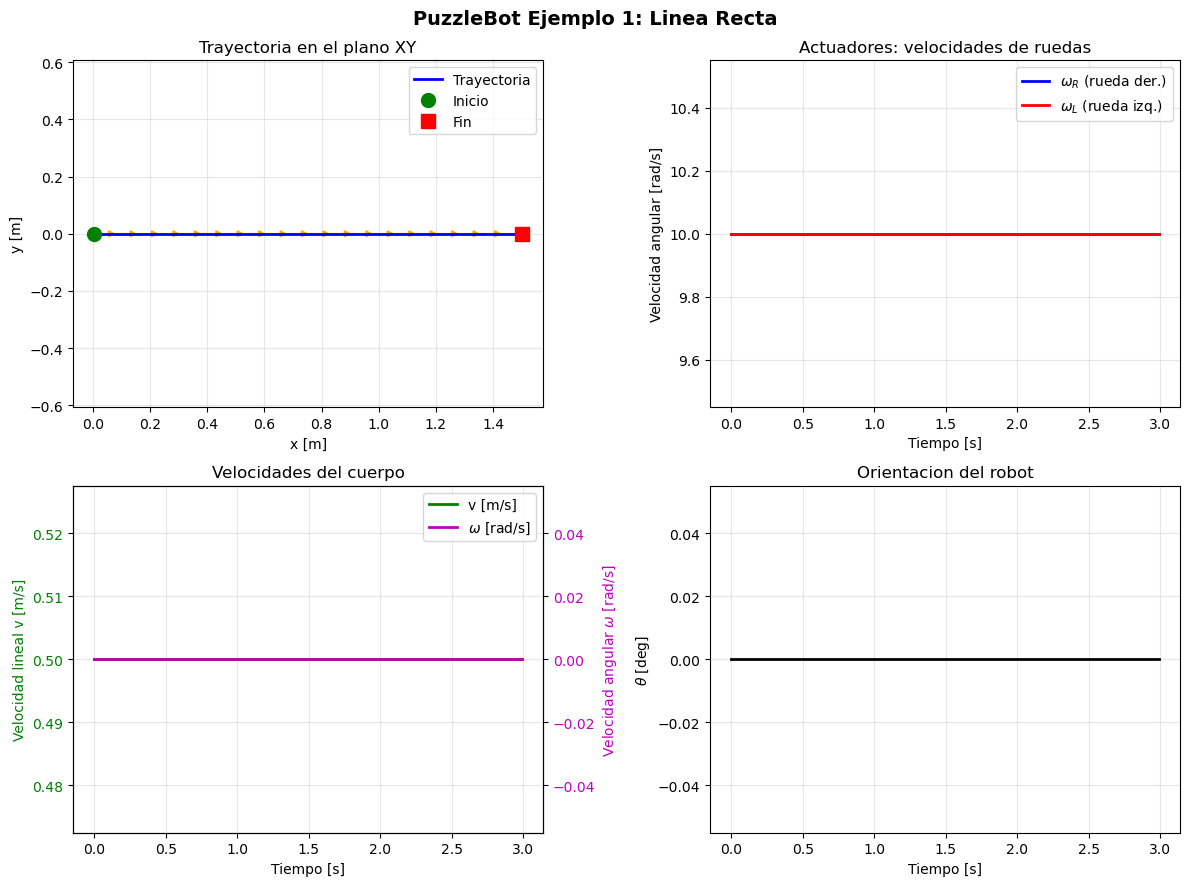

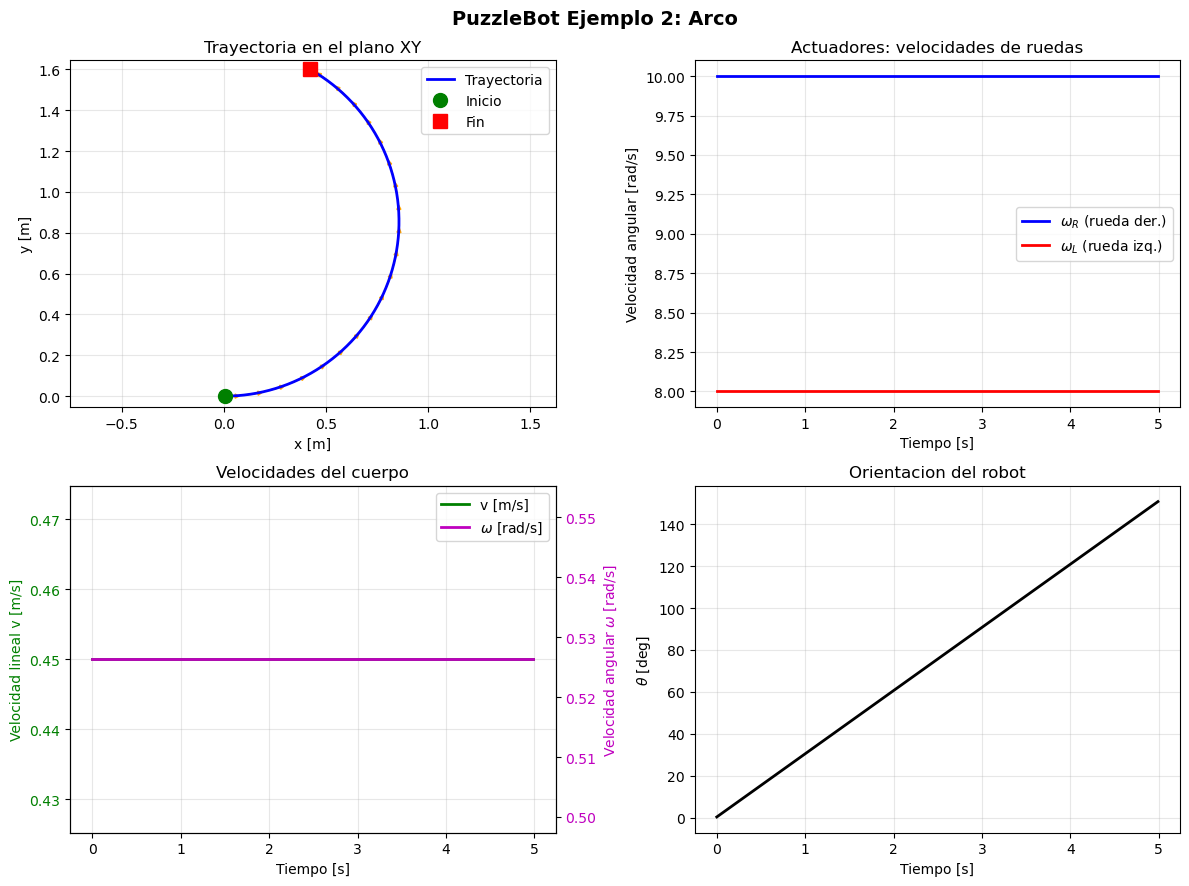

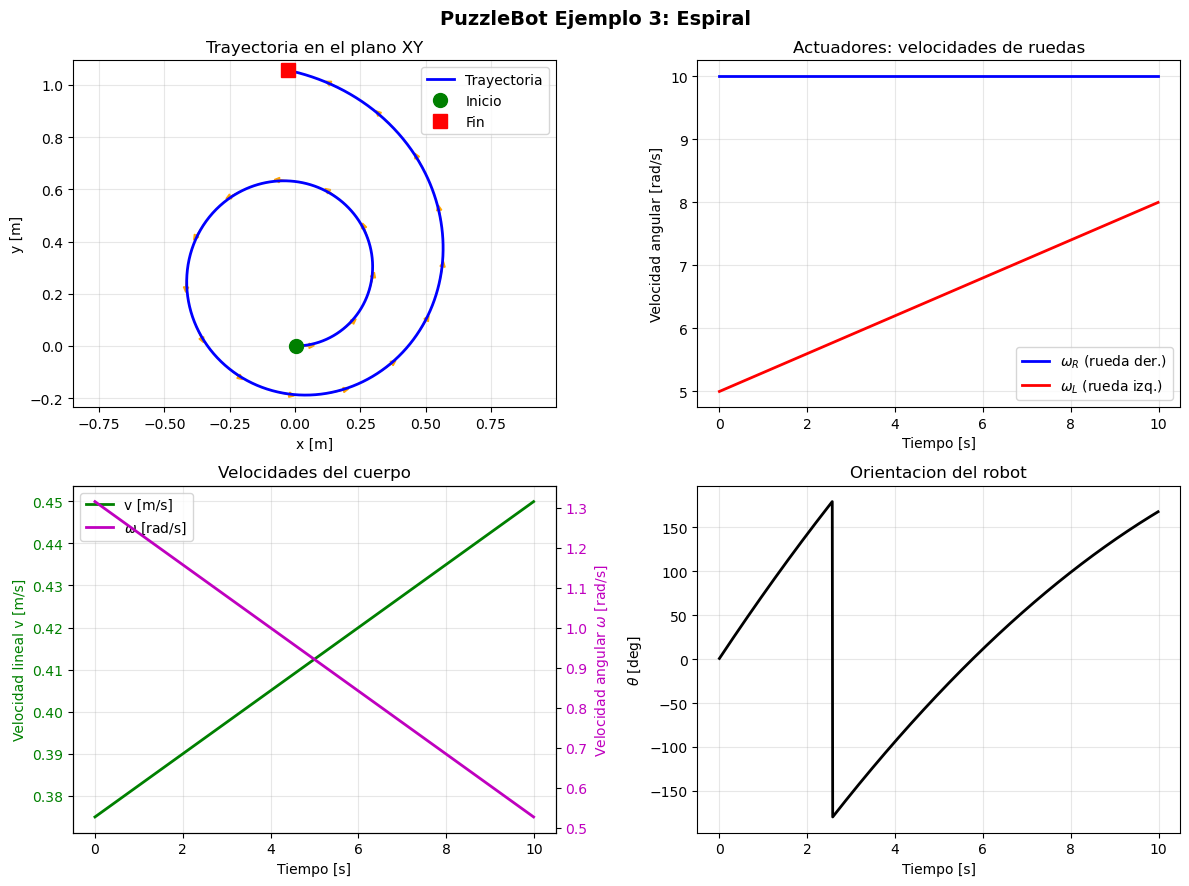

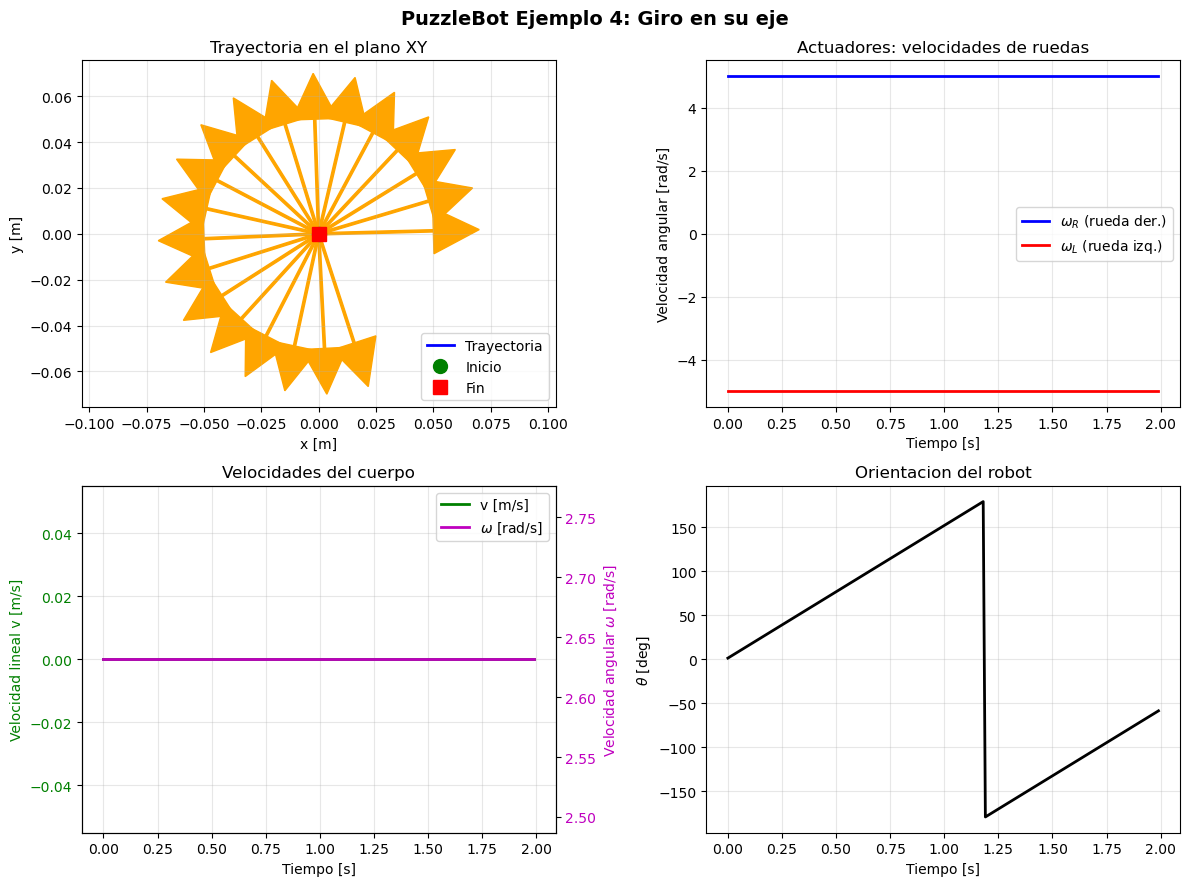

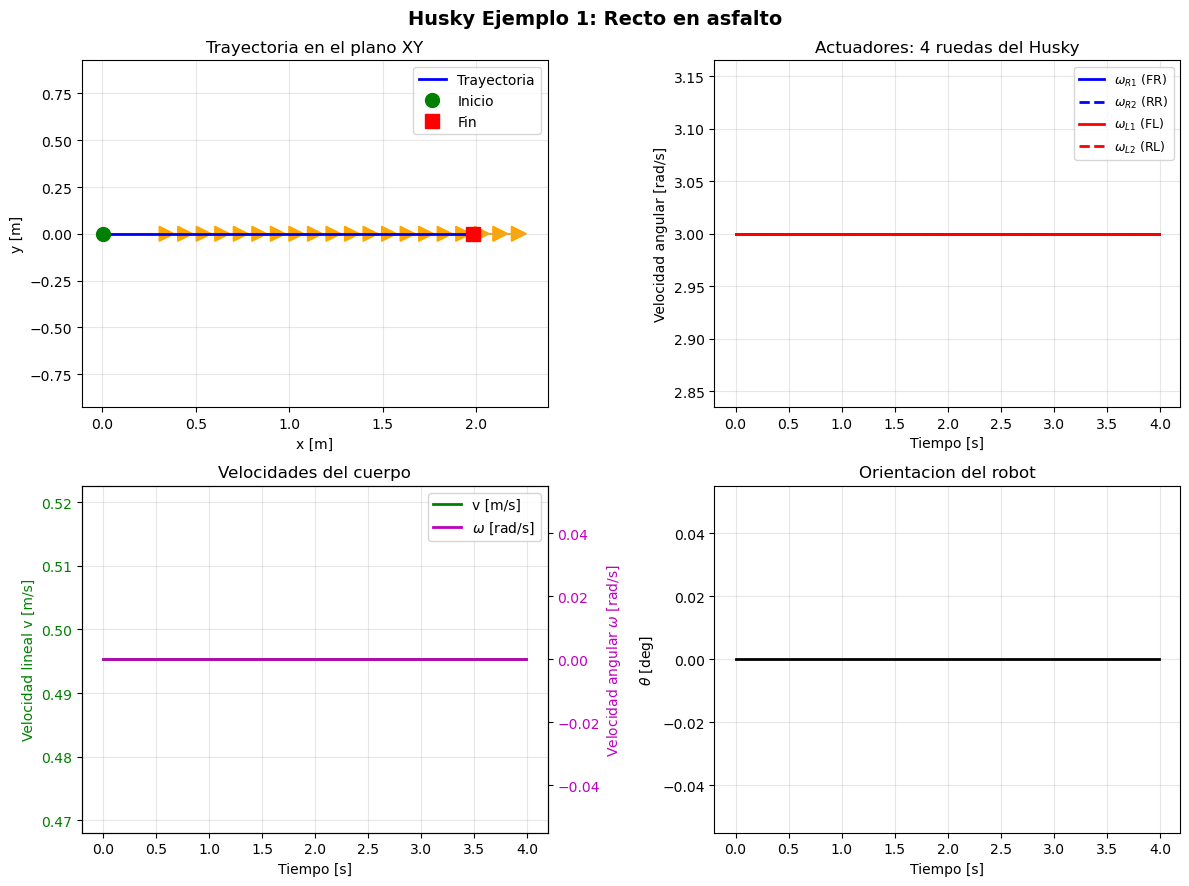

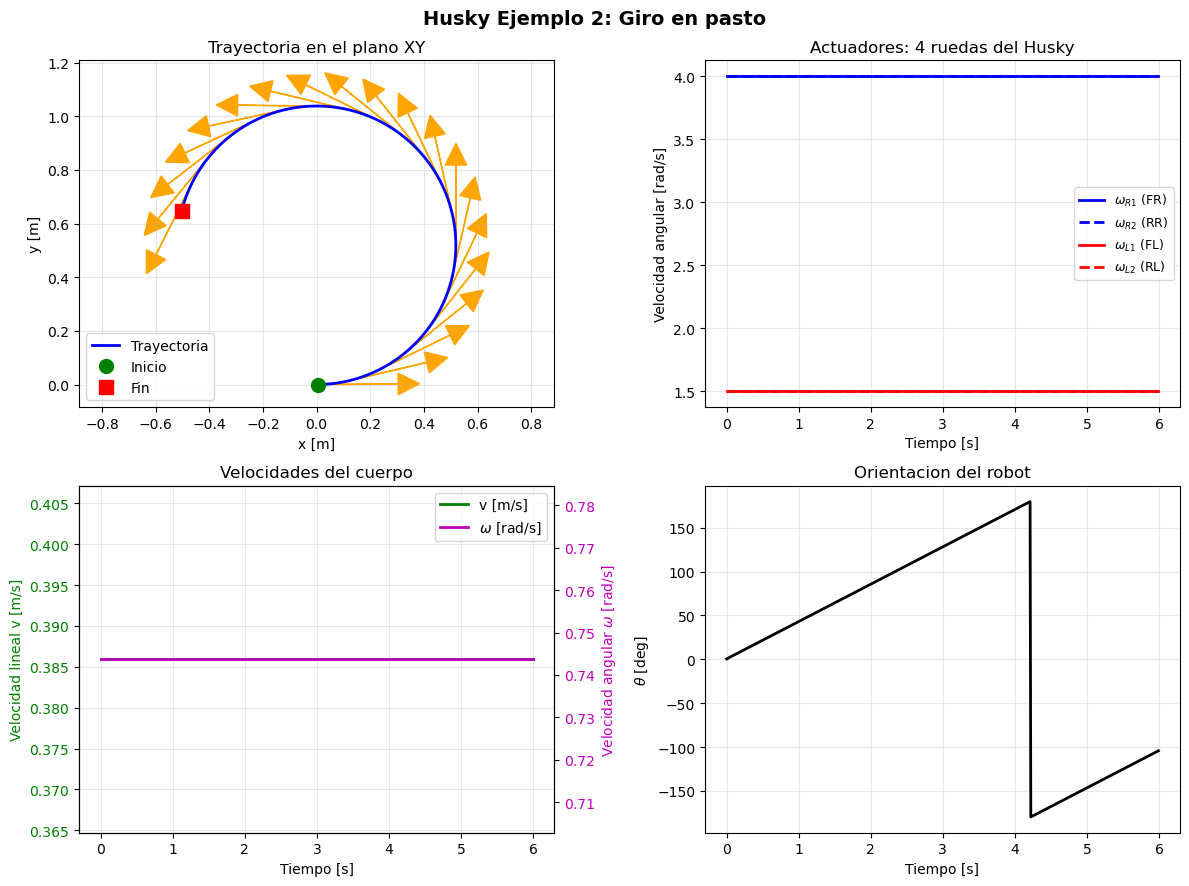

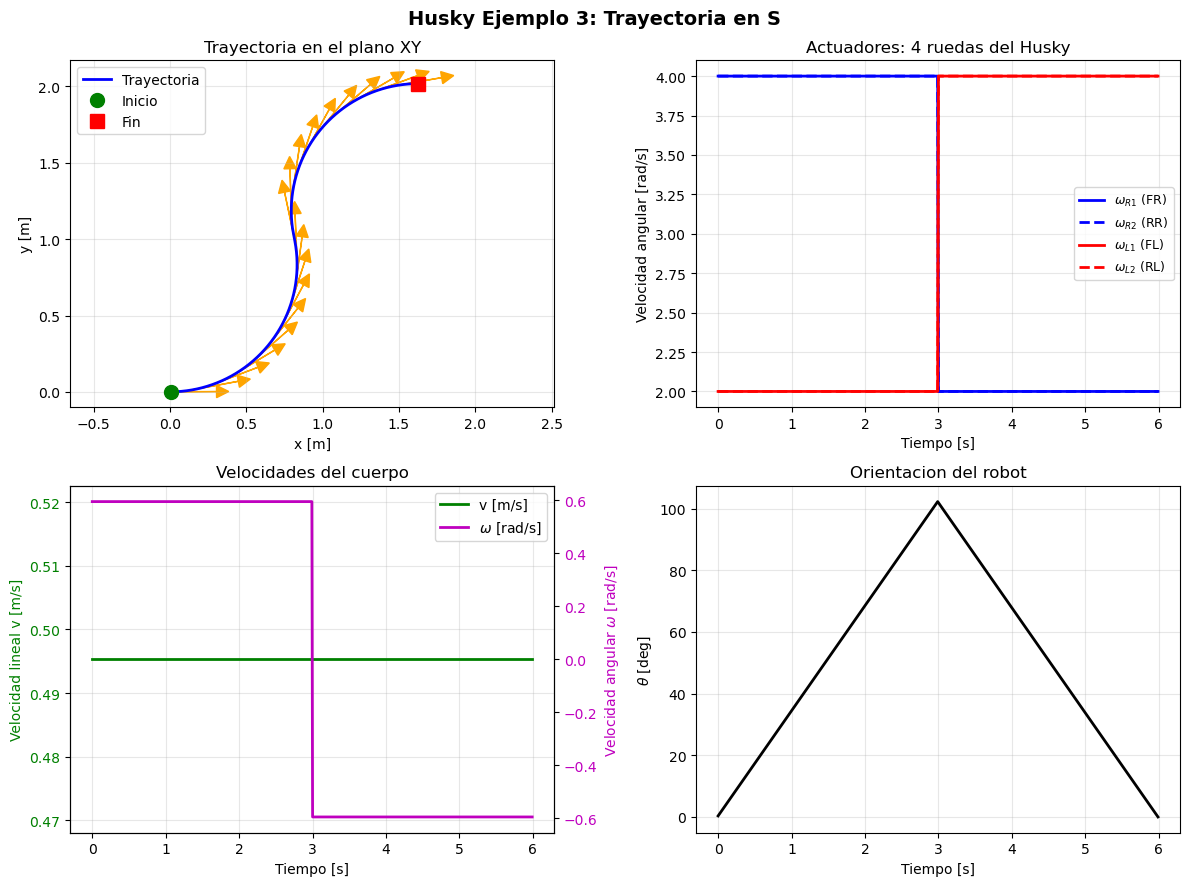

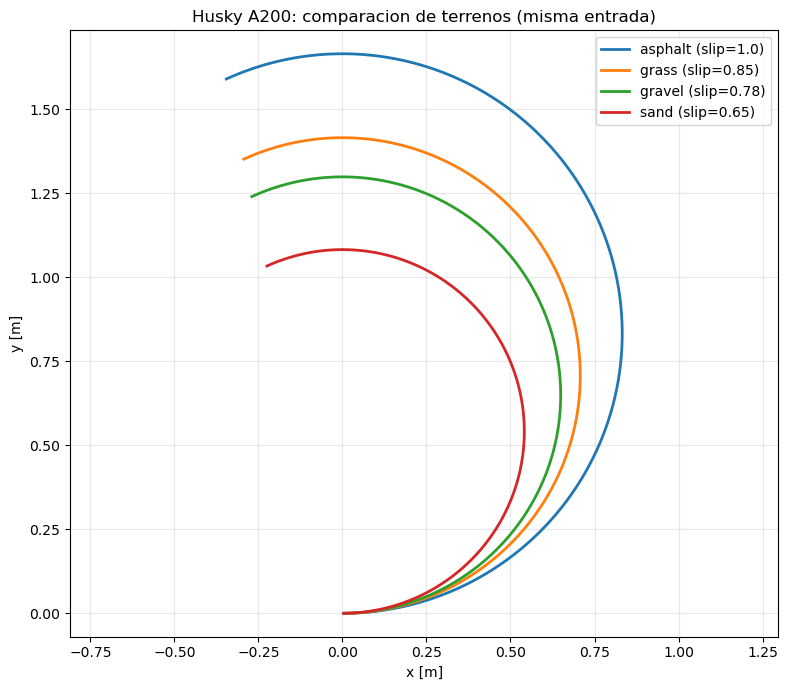

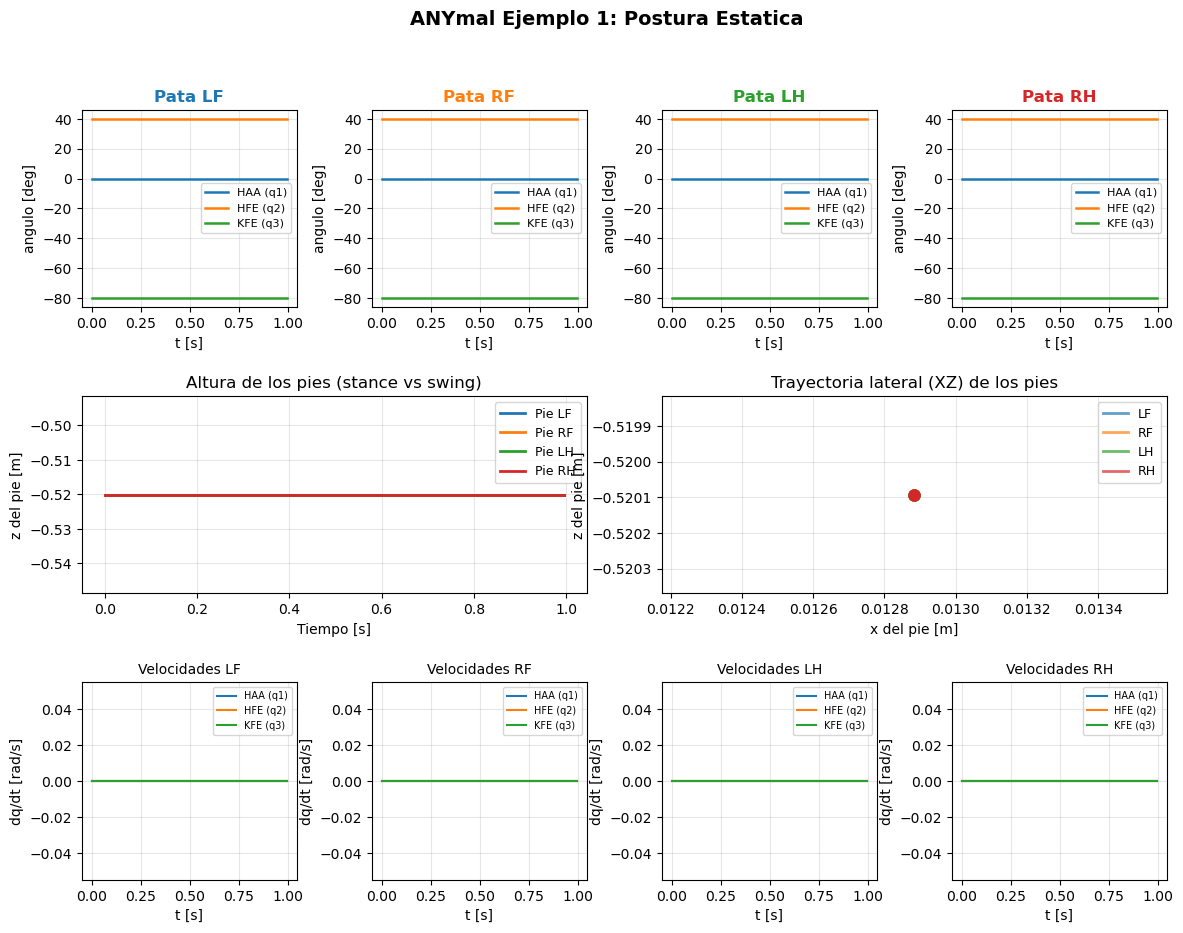

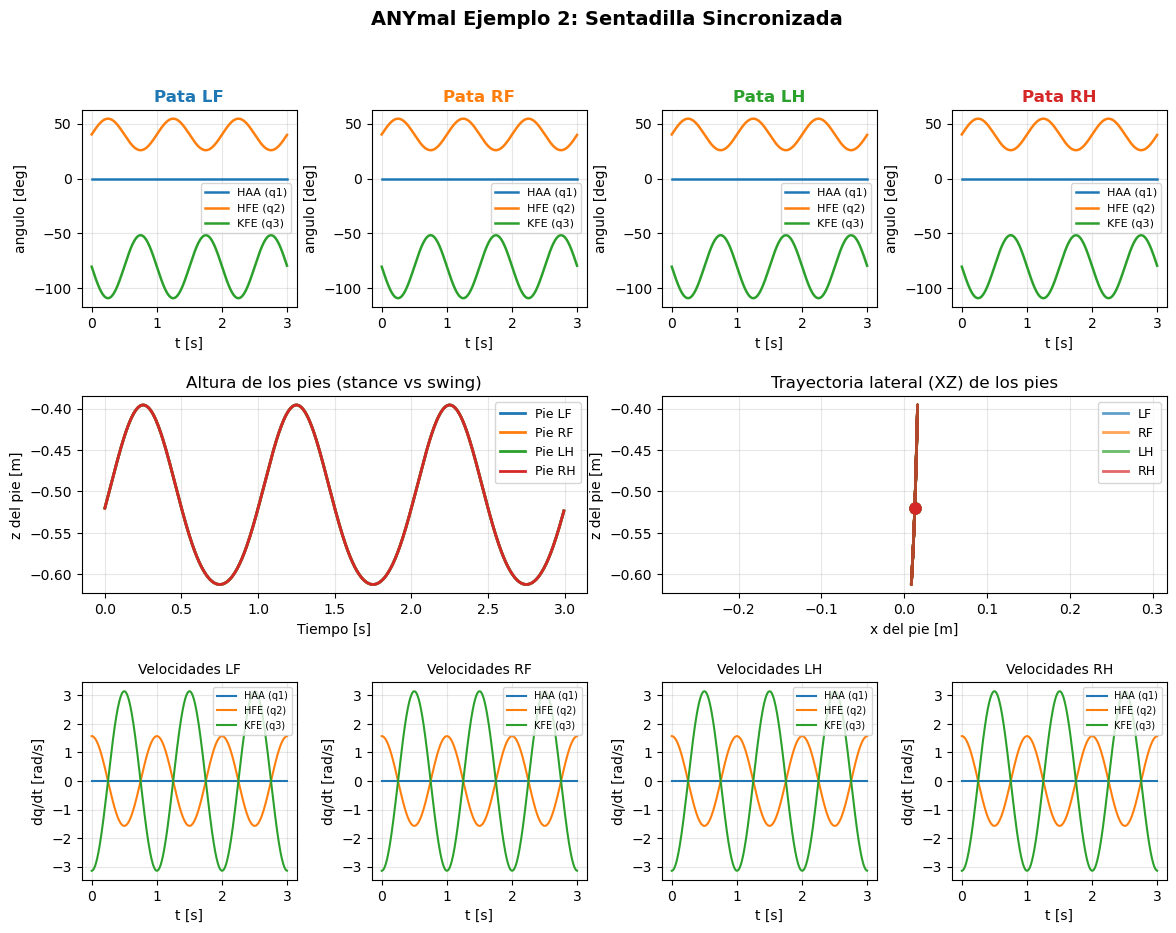

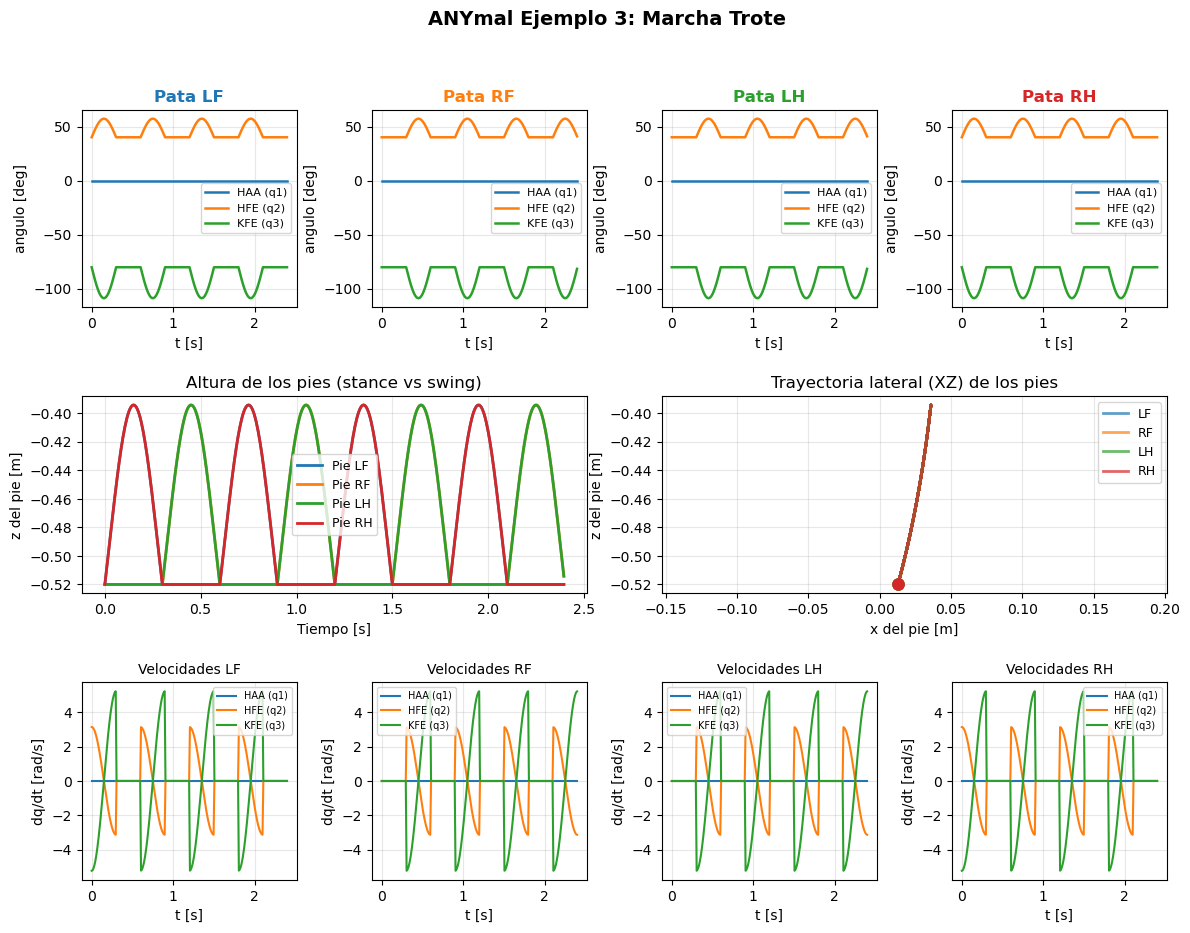

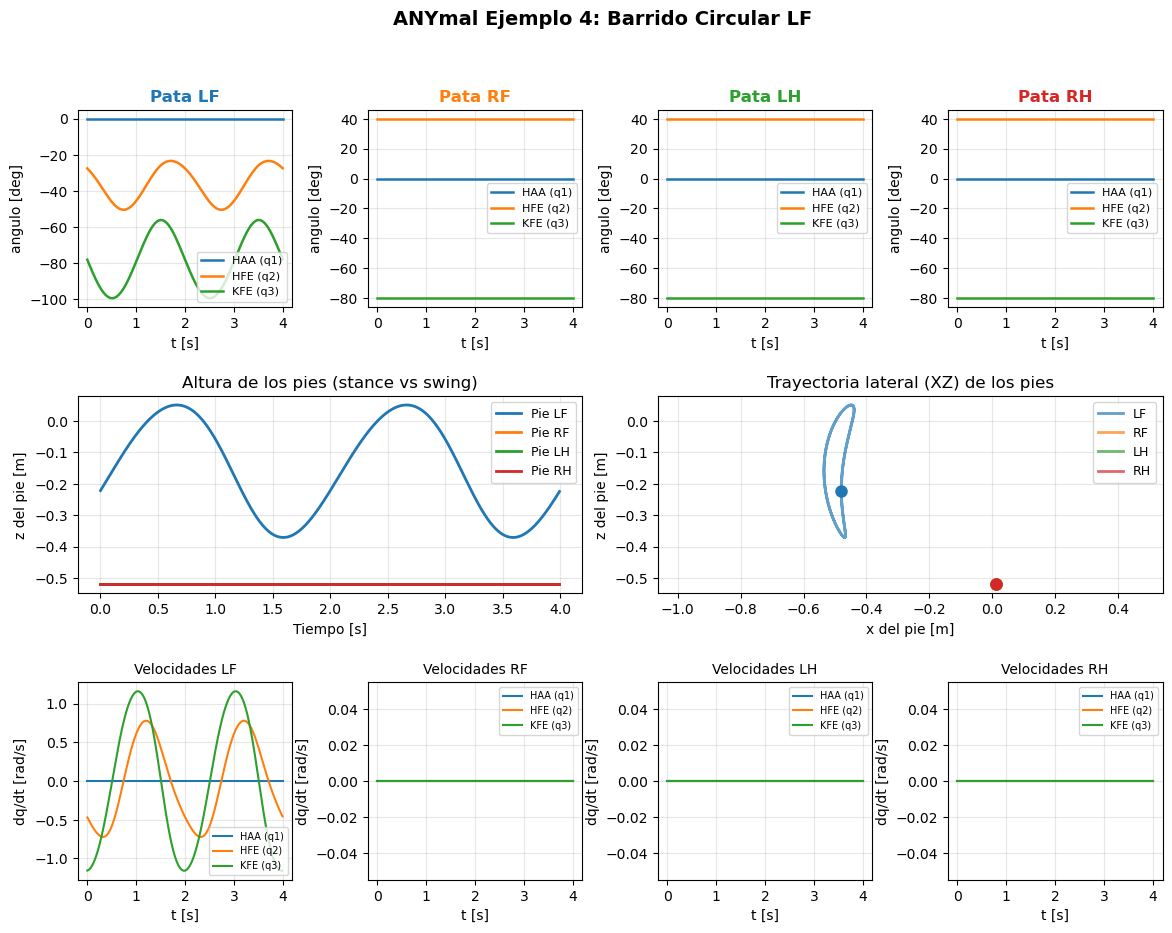

In [1]:
################################################################################
#                                                                              #
#           ROBOTS MOVILES TERRESTRES - CODIGO COMPLETO EN PYTHON              #
#           Curso de 10 Semanas - Computational Robotics Lab                   #
#           Prof. Alberto Munoz                                                #
#           Tecnologico de Monterrey - 2026                                    #
#                                                                              #
#  Contenido:                                                                  #
#    PARTE 1: PuzzleBot  (robot diferencial de 2 ruedas)                       #
#    PARTE 2: Husky A200 (robot skid-steer de 4 ruedas)                        #
#    PARTE 3: ANYmal     (cuadrupedo de 12 DoF)                                #
#                                                                              #
#  Cada parte incluye:                                                         #
#    - Clase del robot con parametros, cinematica directa e inversa            #
#    - Funciones de simulacion de movimiento                                   #
#    - Funciones de graficacion de trayectorias de actuadores                  #
#    - Ejemplos de uso que corren al ejecutar el archivo                       #
#                                                                              #
#  Requisitos: numpy, matplotlib                                               #
#    pip install numpy matplotlib                                              #
#                                                                              #
################################################################################

import numpy as np
import matplotlib.pyplot as plt


################################################################################
#                                                                              #
#                    PARTE 1:  PuzzleBot  (robot diferencial)                  #
#                                                                              #
################################################################################

class PuzzleBot:
    """
    Robot diferencial de 2 ruedas (PuzzleBot Manchester Robotics / Tec de Monterrey).

    Modelo cinematico:
        v     = r/2 * (wR + wL)
        omega = r/L * (wR - wL)

    Atributos:
        r      : radio de la rueda [m]
        L      : distancia entre ruedas (track width) [m]
        x, y   : posicion del robot en el marco mundo [m]
        theta  : orientacion del robot [rad]
    """

    def __init__(self, r=0.05, L=0.19):
        # --- Parametros fisicos (calibrados con el robot real) ---
        self.r = r              # Radio de la rueda [m]
        self.L = L              # Distancia entre ruedas [m]

        # --- Estado interno: pose (x, y, theta) en marco mundo ---
        self.x = 0.0            # Posicion X [m]
        self.y = 0.0            # Posicion Y [m]
        self.theta = 0.0        # Orientacion [rad] en [-pi, pi]

        # --- Limites fisicos del robot (proteccion) ---
        self.v_max = 0.8        # Velocidad lineal maxima [m/s]
        self.omega_max = 3.0    # Velocidad angular maxima [rad/s]

    def forward_kinematics(self, wR, wL):
        """
        Cinematica directa: de velocidades de rueda a (v, omega) del robot.

        Entradas:
            wR : velocidad angular rueda derecha [rad/s]
            wL : velocidad angular rueda izquierda [rad/s]

        Retorna:
            (v, omega) : velocidad lineal [m/s] y angular [rad/s]

        Complejidad: O(1) - 3 operaciones aritmeticas
        """
        # Velocidad lineal = promedio de velocidades de rueda * radio
        v = self.r / 2.0 * (wR + wL)

        # Velocidad angular = diferencia de velocidades escalada por geometria
        omega = self.r / self.L * (wR - wL)

        return v, omega

    def inverse_kinematics(self, v, omega):
        """
        Cinematica inversa: de (v, omega) deseados a velocidades de rueda.

        Entradas:
            v     : velocidad lineal deseada [m/s]
            omega : velocidad angular deseada [rad/s]

        Retorna:
            (wR, wL) : velocidades angulares de ruedas [rad/s]

        Complejidad: O(1) - 4 operaciones aritmeticas

        Uso tipico: el planificador da (v, omega); este metodo traduce
        a referencias que los PIDs de cada motor deben seguir.
        """
        # Saturar velocidades deseadas a los limites fisicos
        v = np.clip(v, -self.v_max, self.v_max)
        omega = np.clip(omega, -self.omega_max, self.omega_max)

        # Cinematica inversa: resolver el sistema lineal 2x2
        #   wR + wL = 2v/r
        #   wR - wL = omega*L/r
        wR = (2.0 * v + omega * self.L) / (2.0 * self.r)
        wL = (2.0 * v - omega * self.L) / (2.0 * self.r)

        return wR, wL

    def update_pose(self, v, omega, dt):
        """
        Integra la pose del robot por Euler explicito.

        Entradas:
            v     : velocidad lineal actual [m/s]
            omega : velocidad angular actual [rad/s]
            dt    : paso de tiempo [s] (tipicamente 0.01 s = 100 Hz)

        Modifica self.x, self.y, self.theta in-place.

        Complejidad: O(1) por paso
        Error de integracion: O(dt) - Euler explicito
        """
        # Actualizar posicion (traslacion en la direccion actual)
        self.x += v * np.cos(self.theta) * dt
        self.y += v * np.sin(self.theta) * dt

        # Actualizar orientacion
        self.theta += omega * dt

        # Normalizar theta al rango [-pi, pi] para evitar acumulacion
        self.theta = np.arctan2(np.sin(self.theta), np.cos(self.theta))

    def get_pose(self):
        """Retorna la pose actual como tupla (x, y, theta)."""
        return (self.x, self.y, self.theta)

    def reset(self, x=0.0, y=0.0, theta=0.0):
        """Resetea el estado del robot a una pose dada."""
        self.x, self.y, self.theta = x, y, theta


def simulate_puzzlebot(bot, wR_func, wL_func, T=5.0, dt=0.01):
    """
    Simula el movimiento del PuzzleBot dadas funciones de velocidad de rueda.

    Entradas:
        bot     : instancia de PuzzleBot
        wR_func : funcion wR(t) -> velocidad rueda derecha [rad/s]
        wL_func : funcion wL(t) -> velocidad rueda izquierda [rad/s]
        T       : tiempo total de simulacion [s]
        dt      : paso de tiempo [s]

    Retorna:
        dict con claves:
            't'     : array de tiempos [s]
            'x','y','theta' : trayectoria de la pose
            'wR','wL'       : trayectoria de velocidades de rueda [rad/s]
            'v','omega'     : trayectoria de velocidades del cuerpo
    """
    bot.reset()
    n_steps = int(T / dt)
    log = {k: np.zeros(n_steps) for k in ['t', 'x', 'y', 'theta',
                                          'wR', 'wL', 'v', 'omega']}

    for i in range(n_steps):
        t = i * dt
        wR = wR_func(t)
        wL = wL_func(t)
        v, omega = bot.forward_kinematics(wR, wL)
        bot.update_pose(v, omega, dt)

        log['t'][i] = t
        log['x'][i] = bot.x
        log['y'][i] = bot.y
        log['theta'][i] = bot.theta
        log['wR'][i] = wR
        log['wL'][i] = wL
        log['v'][i] = v
        log['omega'][i] = omega

    return log


def plot_puzzlebot_trajectory(log, title="PuzzleBot - Trayectoria y Actuadores",
                              save_path=None):
    """
    Grafica la trayectoria XY y las velocidades de los actuadores del PuzzleBot.

    Los actuadores del PuzzleBot son los 2 motores DC (rueda R y rueda L).

    Genera una figura con 4 subplots:
        1. Trayectoria XY en el plano
        2. Velocidades angulares de las ruedas (actuadores) vs tiempo
        3. Velocidades del cuerpo (v, omega) vs tiempo
        4. Orientacion theta vs tiempo
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # --- Subplot 1: trayectoria XY ---
    ax = axes[0, 0]
    ax.plot(log['x'], log['y'], 'b-', linewidth=2, label='Trayectoria')
    ax.plot(log['x'][0], log['y'][0], 'go', markersize=10, label='Inicio')
    ax.plot(log['x'][-1], log['y'][-1], 'rs', markersize=10, label='Fin')
    # Flechas de orientacion cada cierto intervalo
    step = max(1, len(log['t']) // 20)
    for i in range(0, len(log['t']), step):
        dx = 0.05 * np.cos(log['theta'][i])
        dy = 0.05 * np.sin(log['theta'][i])
        ax.arrow(log['x'][i], log['y'][i], dx, dy,
                 head_width=0.02, head_length=0.02, fc='orange', ec='orange')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title('Trayectoria en el plano XY')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

    # --- Subplot 2: velocidades de los actuadores (ruedas) ---
    ax = axes[0, 1]
    ax.plot(log['t'], log['wR'], 'b-', linewidth=2, label=r'$\omega_R$ (rueda der.)')
    ax.plot(log['t'], log['wL'], 'r-', linewidth=2, label=r'$\omega_L$ (rueda izq.)')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Velocidad angular [rad/s]')
    ax.set_title('Actuadores: velocidades de ruedas')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Subplot 3: velocidades del cuerpo ---
    ax = axes[1, 0]
    ax2 = ax.twinx()
    l1 = ax.plot(log['t'], log['v'], 'g-', linewidth=2, label='v [m/s]')
    l2 = ax2.plot(log['t'], log['omega'], 'm-', linewidth=2, label=r'$\omega$ [rad/s]')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Velocidad lineal v [m/s]', color='g')
    ax2.set_ylabel(r'Velocidad angular $\omega$ [rad/s]', color='m')
    ax.tick_params(axis='y', labelcolor='g')
    ax2.tick_params(axis='y', labelcolor='m')
    ax.set_title('Velocidades del cuerpo')
    lines = l1 + l2
    ax.legend(lines, [l.get_label() for l in lines], loc='best')
    ax.grid(True, alpha=0.3)

    # --- Subplot 4: orientacion ---
    ax = axes[1, 1]
    ax.plot(log['t'], np.degrees(log['theta']), 'k-', linewidth=2)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel(r'$\theta$ [deg]')
    ax.set_title('Orientacion del robot')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  -> Figura guardada en {save_path}")
    return fig


def demo_puzzlebot():
    """Ejemplos de movimiento del PuzzleBot con graficacion."""
    print("=" * 70)
    print("DEMO PuzzleBot")
    print("=" * 70)

    bot = PuzzleBot(r=0.05, L=0.19)

    # --- Ejemplo 1: avanzar en linea recta ---
    print("\n[1] Avanzar en linea recta (wR = wL = 10 rad/s)")
    log1 = simulate_puzzlebot(bot,
                              wR_func=lambda t: 10.0,
                              wL_func=lambda t: 10.0,
                              T=3.0)
    print(f"    Pose final: x={log1['x'][-1]:.3f}, y={log1['y'][-1]:.3f}, "
          f"theta={np.degrees(log1['theta'][-1]):.1f} deg")
    plot_puzzlebot_trajectory(log1, title="PuzzleBot Ejemplo 1: Linea Recta",
                              save_path="puzzlebot_ej1_recta.png")

    # --- Ejemplo 2: movimiento en arco ---
    print("\n[2] Movimiento en arco (wR=10, wL=8 rad/s)")
    log2 = simulate_puzzlebot(bot,
                              wR_func=lambda t: 10.0,
                              wL_func=lambda t: 8.0,
                              T=5.0)
    print(f"    Pose final: x={log2['x'][-1]:.3f}, y={log2['y'][-1]:.3f}, "
          f"theta={np.degrees(log2['theta'][-1]):.1f} deg")
    plot_puzzlebot_trajectory(log2, title="PuzzleBot Ejemplo 2: Arco",
                              save_path="puzzlebot_ej2_arco.png")

    # --- Ejemplo 3: espiral (velocidades variables en el tiempo) ---
    print("\n[3] Espiral (wL crece con el tiempo)")
    log3 = simulate_puzzlebot(bot,
                              wR_func=lambda t: 10.0,
                              wL_func=lambda t: 5.0 + 0.3 * t,
                              T=10.0)
    print(f"    Pose final: x={log3['x'][-1]:.3f}, y={log3['y'][-1]:.3f}, "
          f"theta={np.degrees(log3['theta'][-1]):.1f} deg")
    plot_puzzlebot_trajectory(log3, title="PuzzleBot Ejemplo 3: Espiral",
                              save_path="puzzlebot_ej3_espiral.png")

    # --- Ejemplo 4: giro en el propio eje ---
    print("\n[4] Giro sobre el propio eje (wR = -wL)")
    log4 = simulate_puzzlebot(bot,
                              wR_func=lambda t: 5.0,
                              wL_func=lambda t: -5.0,
                              T=2.0)
    print(f"    Pose final: x={log4['x'][-1]:.3f}, y={log4['y'][-1]:.3f}, "
          f"theta={np.degrees(log4['theta'][-1]):.1f} deg")
    plot_puzzlebot_trajectory(log4, title="PuzzleBot Ejemplo 4: Giro en su eje",
                              save_path="puzzlebot_ej4_giro.png")


################################################################################
#                                                                              #
#                    PARTE 2:  Husky A200  (skid-steer 4 ruedas)               #
#                                                                              #
################################################################################

class HuskyA200:
    """
    Husky A200 de Clearpath Robotics - Robot skid-steer de 4 ruedas.

    El skid-steer NO tiene mecanismo de direccion: el giro se logra
    variando la velocidad entre los dos lados (como un tanque).
    Esto implica deslizamiento lateral durante el giro.
    """

    def __init__(self, r=0.1651, B=0.555, mass=50.0):
        # --- Parametros geometricos ---
        self.r = r              # Radio de la rueda [m]
        self.B = B              # Distancia efectiva entre lados [m]
        # B debe calibrarse experimentalmente ya que el skid-steer
        # tiene un "centro instantaneo de rotacion" (ICR) virtual

        # --- Parametros inerciales ---
        self.mass = mass        # Masa [kg] sin payload
        self.payload_max = 75.0 # Payload maximo [kg]

        # --- Estado (pose y velocidades) ---
        self.x, self.y, self.theta = 0.0, 0.0, 0.0
        self.v, self.omega = 0.0, 0.0

        # --- Terreno actual (afecta deslizamiento) ---
        self.terrain = "asphalt"
        self._slip_factors = {
            "asphalt": 1.00,    # Superficie ideal
            "grass":   0.85,    # Pasto cortado
            "gravel":  0.78,    # Grava suelta
            "sand":    0.65,    # Arena
            "mud":     0.50,    # Lodo
        }

    def forward_kinematics(self, wR1, wR2, wL1, wL2):
        """
        Cinematica directa para skid-steer de 4 ruedas.

        Entradas:
            wR1, wR2 : velocidades ruedas derechas (frontal, trasera) [rad/s]
            wL1, wL2 : velocidades ruedas izquierdas [rad/s]

        Retorna:
            (v, omega) : velocidades del cuerpo del robot

        Complejidad: O(1)
        """
        # Promediar cada lado: el modelo asume ruedas del mismo lado
        # giran a la misma velocidad (idealizacion)
        avg_R = (wR1 + wR2) / 2.0
        avg_L = (wL1 + wL2) / 2.0

        # Aplicar factor de deslizamiento del terreno actual
        slip = self._slip_factors.get(self.terrain, 0.8)

        # Velocidades del cuerpo
        v = self.r / 2.0 * (avg_R + avg_L) * slip
        omega = self.r / self.B * (avg_R - avg_L)

        return v, omega

    def inverse_kinematics(self, v, omega):
        """
        Cinematica inversa: (v, omega) -> velocidades de las 4 ruedas.
        Se asume que las ruedas de cada lado giran a la misma velocidad.
        """
        wR = (2.0 * v + omega * self.B) / (2.0 * self.r)
        wL = (2.0 * v - omega * self.B) / (2.0 * self.r)
        return wR, wR, wL, wL   # (wR1, wR2, wL1, wL2)

    def update_pose(self, v, omega, dt):
        """Integra la pose usando el metodo del punto medio (midpoint)."""
        # Orientacion en el punto medio del intervalo (mas preciso que Euler)
        theta_mid = self.theta + omega * dt / 2.0

        self.x += v * np.cos(theta_mid) * dt
        self.y += v * np.sin(theta_mid) * dt
        self.theta += omega * dt
        self.theta = np.arctan2(np.sin(self.theta), np.cos(self.theta))

        # Guardar velocidades para el siguiente ciclo
        self.v, self.omega = v, omega

    def set_terrain(self, terrain_name):
        """Cambia el terreno actual (afecta factor de deslizamiento)."""
        self.terrain = terrain_name

    def get_pose(self):
        """Retorna la pose actual como tupla (x, y, theta)."""
        return (self.x, self.y, self.theta)

    def reset(self, x=0.0, y=0.0, theta=0.0):
        """Resetea el estado del robot."""
        self.x, self.y, self.theta = x, y, theta
        self.v, self.omega = 0.0, 0.0


def simulate_husky(husky, wheel_funcs, T=5.0, dt=0.01):
    """
    Simula el movimiento del Husky A200.

    Entradas:
        husky       : instancia de HuskyA200
        wheel_funcs : tupla (wR1_func, wR2_func, wL1_func, wL2_func)
                      cada una funcion de t -> rad/s
        T           : tiempo de simulacion [s]
        dt          : paso de tiempo [s]

    Retorna:
        dict con trayectorias de pose, 4 velocidades de rueda, y velocidades del cuerpo.
    """
    husky.reset()
    wR1_func, wR2_func, wL1_func, wL2_func = wheel_funcs
    n_steps = int(T / dt)
    log = {k: np.zeros(n_steps) for k in
           ['t', 'x', 'y', 'theta',
            'wR1', 'wR2', 'wL1', 'wL2', 'v', 'omega']}

    for i in range(n_steps):
        t = i * dt
        wR1 = wR1_func(t)
        wR2 = wR2_func(t)
        wL1 = wL1_func(t)
        wL2 = wL2_func(t)
        v, omega = husky.forward_kinematics(wR1, wR2, wL1, wL2)
        husky.update_pose(v, omega, dt)

        log['t'][i] = t
        log['x'][i] = husky.x
        log['y'][i] = husky.y
        log['theta'][i] = husky.theta
        log['wR1'][i] = wR1
        log['wR2'][i] = wR2
        log['wL1'][i] = wL1
        log['wL2'][i] = wL2
        log['v'][i] = v
        log['omega'][i] = omega

    return log


def plot_husky_trajectory(log, title="Husky A200 - Trayectoria y Actuadores",
                          save_path=None):
    """
    Grafica la trayectoria y las velocidades de los 4 actuadores del Husky.

    Los actuadores del Husky son los 4 motores DC (FL, FR, RL, RR).

    Genera una figura con 4 subplots:
        1. Trayectoria XY con flechas de orientacion
        2. Velocidades angulares de las 4 ruedas (actuadores)
        3. Velocidades del cuerpo (v, omega)
        4. Orientacion theta vs tiempo
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # --- Subplot 1: trayectoria XY ---
    ax = axes[0, 0]
    ax.plot(log['x'], log['y'], 'b-', linewidth=2, label='Trayectoria')
    ax.plot(log['x'][0], log['y'][0], 'go', markersize=10, label='Inicio')
    ax.plot(log['x'][-1], log['y'][-1], 'rs', markersize=10, label='Fin')
    step = max(1, len(log['t']) // 20)
    for i in range(0, len(log['t']), step):
        dx = 0.3 * np.cos(log['theta'][i])
        dy = 0.3 * np.sin(log['theta'][i])
        ax.arrow(log['x'][i], log['y'][i], dx, dy,
                 head_width=0.08, head_length=0.08, fc='orange', ec='orange')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title('Trayectoria en el plano XY')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

    # --- Subplot 2: velocidades de las 4 ruedas (actuadores) ---
    ax = axes[0, 1]
    ax.plot(log['t'], log['wR1'], 'b-', linewidth=2, label=r'$\omega_{R1}$ (FR)')
    ax.plot(log['t'], log['wR2'], 'b--', linewidth=2, label=r'$\omega_{R2}$ (RR)')
    ax.plot(log['t'], log['wL1'], 'r-', linewidth=2, label=r'$\omega_{L1}$ (FL)')
    ax.plot(log['t'], log['wL2'], 'r--', linewidth=2, label=r'$\omega_{L2}$ (RL)')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Velocidad angular [rad/s]')
    ax.set_title('Actuadores: 4 ruedas del Husky')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Subplot 3: velocidades del cuerpo ---
    ax = axes[1, 0]
    ax2 = ax.twinx()
    l1 = ax.plot(log['t'], log['v'], 'g-', linewidth=2, label='v [m/s]')
    l2 = ax2.plot(log['t'], log['omega'], 'm-', linewidth=2, label=r'$\omega$ [rad/s]')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Velocidad lineal v [m/s]', color='g')
    ax2.set_ylabel(r'Velocidad angular $\omega$ [rad/s]', color='m')
    ax.tick_params(axis='y', labelcolor='g')
    ax2.tick_params(axis='y', labelcolor='m')
    ax.set_title('Velocidades del cuerpo')
    lines = l1 + l2
    ax.legend(lines, [l.get_label() for l in lines], loc='best')
    ax.grid(True, alpha=0.3)

    # --- Subplot 4: orientacion ---
    ax = axes[1, 1]
    ax.plot(log['t'], np.degrees(log['theta']), 'k-', linewidth=2)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel(r'$\theta$ [deg]')
    ax.set_title('Orientacion del robot')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  -> Figura guardada en {save_path}")
    return fig


def demo_husky():
    """Ejemplos de movimiento del Husky A200 con graficacion."""
    print("=" * 70)
    print("DEMO Husky A200")
    print("=" * 70)

    husky = HuskyA200()

    # --- Ejemplo 1: avance recto sobre asfalto ---
    print("\n[1] Avance recto sobre asfalto")
    husky.set_terrain("asphalt")
    log1 = simulate_husky(husky,
                          wheel_funcs=(lambda t: 3.0, lambda t: 3.0,
                                       lambda t: 3.0, lambda t: 3.0),
                          T=4.0)
    print(f"    Pose final: x={log1['x'][-1]:.3f}, y={log1['y'][-1]:.3f}")
    plot_husky_trajectory(log1, title="Husky Ejemplo 1: Recto en asfalto",
                          save_path="husky_ej1_recto.png")

    # --- Ejemplo 2: giro sobre pasto (con slip) ---
    print("\n[2] Giro sobre pasto (slip=0.85)")
    husky.set_terrain("grass")
    log2 = simulate_husky(husky,
                          wheel_funcs=(lambda t: 4.0, lambda t: 4.0,
                                       lambda t: 1.5, lambda t: 1.5),
                          T=6.0)
    print(f"    Pose final: x={log2['x'][-1]:.3f}, y={log2['y'][-1]:.3f}, "
          f"theta={np.degrees(log2['theta'][-1]):.1f} deg")
    plot_husky_trajectory(log2, title="Husky Ejemplo 2: Giro en pasto",
                          save_path="husky_ej2_giro.png")

    # --- Ejemplo 3: trayectoria en S (cambio de direccion de giro) ---
    print("\n[3] Trayectoria en S (cambio de direccion de giro)")
    husky.set_terrain("asphalt")

    def wheel_S(t):
        """Genera comando en S: primero gira a la derecha, luego a la izquierda."""
        if t < 3.0:
            return 4.0, 2.0     # giro derecha
        else:
            return 2.0, 4.0     # giro izquierda

    def wR_s(t): return wheel_S(t)[0]
    def wL_s(t): return wheel_S(t)[1]

    log3 = simulate_husky(husky,
                          wheel_funcs=(wR_s, wR_s, wL_s, wL_s),
                          T=6.0)
    print(f"    Pose final: x={log3['x'][-1]:.3f}, y={log3['y'][-1]:.3f}")
    plot_husky_trajectory(log3, title="Husky Ejemplo 3: Trayectoria en S",
                          save_path="husky_ej3_S.png")

    # --- Ejemplo 4: comparacion de terrenos (misma entrada, diferente slip) ---
    print("\n[4] Comparacion de 4 terrenos con la misma entrada")
    terrains = ["asphalt", "grass", "gravel", "sand"]
    fig, ax = plt.subplots(figsize=(8, 7))
    for terrain in terrains:
        husky.set_terrain(terrain)
        log = simulate_husky(husky,
                             wheel_funcs=(lambda t: 4.0, lambda t: 4.0,
                                          lambda t: 2.0, lambda t: 2.0),
                             T=6.0)
        slip = husky._slip_factors[terrain]
        ax.plot(log['x'], log['y'], linewidth=2,
                label=f"{terrain} (slip={slip})")
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_title('Husky A200: comparacion de terrenos (misma entrada)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    plt.tight_layout()
    plt.savefig("husky_ej4_terrenos.png", dpi=150, bbox_inches='tight')
    print("  -> Figura guardada en husky_ej4_terrenos.png")


################################################################################
#                                                                              #
#                    PARTE 3:  ANYmal  (cuadrupedo de 12 DoF)                  #
#                                                                              #
################################################################################

class ANYmalLeg:
    """
    Una pata del ANYmal con 3 articulaciones (HAA, HFE, KFE).

    Convenciones:
        - Marco de referencia en el hombro (hip) de la pata
        - Eje X: hacia adelante
        - Eje Y: lateral (positivo = hacia afuera)
        - Eje Z: hacia arriba
        - side = +1 para patas izquierdas (LF, LH)
        - side = -1 para patas derechas (RF, RH)

    Las 3 articulaciones (actuadores) son:
        q1 = HAA (Hip Abduction/Adduction)
        q2 = HFE (Hip Flexion/Extension)
        q3 = KFE (Knee Flexion/Extension)
    """

    def __init__(self, name, l0=0.0585, l1=0.35, l2=0.33, side=1):
        # --- Identificacion ---
        self.name = name            # 'LF', 'RF', 'LH', 'RH'

        # --- Longitudes de eslabones (valores tipicos ANYmal) ---
        self.l0 = l0                # Longitud del brazo HAA [m]
        self.l1 = l1                # Longitud del muslo (thigh) [m]
        self.l2 = l2                # Longitud de la espinilla (shank) [m]

        # --- Lado (afecta signo de y) ---
        self.side = side            # +1 = izq, -1 = der

        # --- Estado articular ---
        self.q = np.zeros(3)        # [q_HAA, q_HFE, q_KFE] [rad]

        # --- Limites articulares (seguridad) ---
        self.q_min = np.array([-0.72, -9.42, -2.69])    # [rad]
        self.q_max = np.array([ 0.49,  9.42, -0.03])    # [rad]

    def forward_kinematics(self, q=None):
        """
        FK analitica: (q1, q2, q3) -> posicion del pie [x, y, z].

        Entradas:
            q : array [q1, q2, q3] [rad]. Si es None, usa self.q

        Retorna:
            p : np.array([x, y, z]) posicion del pie en marco hombro [m]

        Complejidad: O(1) - 6 trig + 8 mult/sum
        """
        if q is not None:
            self.q = np.asarray(q, dtype=float)
        q1, q2, q3 = self.q

        # Coordenada X (adelante/atras)
        # Contribuciones del muslo (l1) y espinilla (l2)
        x = self.l1 * np.sin(q2) + self.l2 * np.sin(q2 + q3)

        # Coordenada Y (lateral)
        # El lado (+1/-1) determina direccion; solo depende de q1 (HAA)
        y = self.side * self.l0 * np.cos(q1)

        # Coordenada Z (arriba/abajo) - negativo porque cuelga del hombro
        z = -self.l1 * np.cos(q2) - self.l2 * np.cos(q2 + q3)

        return np.array([x, y, z])

    def inverse_kinematics(self, p_des):
        """
        IK geometrica: posicion deseada del pie -> angulos articulares.

        Entrada:
            p_des : np.array([x, y, z]) posicion deseada [m]

        Retorna:
            q : np.array([q1, q2, q3]) angulos articulares [rad]

        Asume configuracion "rodilla hacia atras" (q3 < 0).
        Complejidad: O(1) - ~20 operaciones trig
        """
        x, y, z = p_des

        # --- Paso 1: HAA (q1) - abduccion de la cadera ---
        # Proyeccion en el plano YZ
        r_yz_sq = y**2 + z**2 - self.l0**2
        r_yz = np.sqrt(max(r_yz_sq, 1e-9))
        q1 = np.arctan2(y, -z) - np.arctan2(self.side * self.l0, r_yz)

        # --- Paso 2: KFE (q3) - angulo de la rodilla (ley de cosenos) ---
        r_sq = x**2 + z**2
        D = (r_sq - self.l1**2 - self.l2**2) / (2.0 * self.l1 * self.l2)
        D = np.clip(D, -1.0, 1.0)       # Proteger arccos de NaN
        q3 = -np.arccos(D)              # Negativo = rodilla atras

        # --- Paso 3: HFE (q2) - flexion de la cadera ---
        alpha = np.arctan2(x, -z)
        beta = np.arctan2(self.l2 * np.sin(-q3),
                          self.l1 + self.l2 * np.cos(q3))
        q2 = alpha - beta

        return np.array([q1, q2, q3])

    def jacobian(self, q=None):
        """
        Jacobiano analitico 3x3: dp_pie/dq.

        J[i,j] = derivada parcial de la coord. i del pie respecto a q_j.

        Retorna:
            J : np.ndarray 3x3

        Uso: control de impedancia, deteccion de singularidades.
        Complejidad: O(1) - 6 trig + 12 mult
        """
        if q is None:
            q = self.q
        q1, q2, q3 = q
        J = np.zeros((3, 3))

        # Fila 0: dx/dq (la coord x no depende de q1)
        J[0, 0] = 0.0
        J[0, 1] = self.l1 * np.cos(q2) + self.l2 * np.cos(q2 + q3)
        J[0, 2] = self.l2 * np.cos(q2 + q3)

        # Fila 1: dy/dq (la coord y solo depende de q1)
        J[1, 0] = -self.side * self.l0 * np.sin(q1)
        J[1, 1] = 0.0
        J[1, 2] = 0.0

        # Fila 2: dz/dq
        J[2, 0] = 0.0
        J[2, 1] = self.l1 * np.sin(q2) + self.l2 * np.sin(q2 + q3)
        J[2, 2] = self.l2 * np.sin(q2 + q3)

        return J

    def is_singular(self, q=None, tol=1e-3):
        """Retorna True si la pata esta cerca de una singularidad."""
        return abs(np.linalg.det(self.jacobian(q))) < tol


class ANYmal:
    """
    Cuadrupedo ANYmal completo con 4 patas y 12 DoF.

    Estructura:
        - 4 instancias de ANYmalLeg (LF, RF, LH, RH)
        - Base flotante con 6 DoF (no controlados directamente)
    """

    LEG_NAMES = ['LF', 'RF', 'LH', 'RH']

    def __init__(self):
        # --- Las 4 patas ---
        # LF = Left Front, RF = Right Front, LH = Left Hind, RH = Right Hind
        self.legs = {
            'LF': ANYmalLeg('LF', side=+1),
            'RF': ANYmalLeg('RF', side=-1),
            'LH': ANYmalLeg('LH', side=+1),
            'RH': ANYmalLeg('RH', side=-1),
        }

        # --- Estado del cuerpo (base flotante) ---
        self.base_pos = np.array([0.0, 0.0, 0.45])  # Altura nominal
        self.base_R = np.eye(3)                      # Matriz rotacion base

        # --- Parametros dinamicos ---
        self.mass = 30.0        # Masa total [kg]
        self.n_legs = 4
        self.n_dof_legs = 12    # 3 DoF * 4 patas

    def get_all_joint_angles(self):
        """Retorna un array de 12 elementos con todos los angulos articulares."""
        return np.concatenate([self.legs[name].q for name in self.LEG_NAMES])

    def set_all_joint_angles(self, q12):
        """Establece los 12 angulos articulares. q12 debe tener 12 elementos."""
        q12 = np.asarray(q12)
        assert q12.shape == (12,), f"Se esperan 12 angulos, se recibieron {q12.shape}"
        for i, name in enumerate(self.LEG_NAMES):
            self.legs[name].q = q12[3*i : 3*(i+1)].copy()

    def get_all_foot_positions(self):
        """Retorna un dict con la posicion 3D de cada pie en su marco de hombro."""
        return {name: self.legs[name].forward_kinematics()
                for name in self.LEG_NAMES}


def simulate_anymal_motion(anymal, joint_func, T=2.0, dt=0.005):
    """
    Simula una trayectoria articular del ANYmal.

    Entradas:
        anymal     : instancia de ANYmal
        joint_func : funcion joint_func(t) -> array de 12 elementos [rad]
                     (los 12 angulos articulares como funcion del tiempo)
        T          : tiempo total de simulacion [s]
        dt         : paso de tiempo [s]

    Retorna:
        dict con:
            't'      : array de tiempos [s]
            'q'      : array (n_steps, 12) con todos los angulos
            'feet'   : dict name -> array (n_steps, 3) con posicion del pie
    """
    n_steps = int(T / dt)
    log = {
        't': np.zeros(n_steps),
        'q': np.zeros((n_steps, 12)),
        'feet': {name: np.zeros((n_steps, 3)) for name in ANYmal.LEG_NAMES},
    }

    for i in range(n_steps):
        t = i * dt
        q12 = joint_func(t)
        anymal.set_all_joint_angles(q12)
        foot_positions = anymal.get_all_foot_positions()

        log['t'][i] = t
        log['q'][i, :] = q12
        for name in ANYmal.LEG_NAMES:
            log['feet'][name][i, :] = foot_positions[name]

    return log


def plot_anymal_trajectory(log, title="ANYmal - Actuadores y Trayectoria de Pies",
                           save_path=None):
    """
    Grafica las trayectorias articulares y de los pies del ANYmal.

    Los actuadores del ANYmal son los 12 motores articulares (3 por pata).

    Genera una figura con 6 subplots:
        1-4. Para cada pata: los 3 angulos articulares (HAA, HFE, KFE) vs tiempo
        5.   Altura z de cada pie vs tiempo (muestra swing/stance)
        6.   Trayectoria XZ del pie LF (plano lateral)
    """
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

    leg_colors = {'LF': 'tab:blue', 'RF': 'tab:orange',
                  'LH': 'tab:green', 'RH': 'tab:red'}
    joint_labels = ['HAA (q1)', 'HFE (q2)', 'KFE (q3)']

    # --- Subplots 1-4: angulos articulares de cada pata ---
    for i, name in enumerate(ANYmal.LEG_NAMES):
        ax = fig.add_subplot(gs[0, i])
        q_leg = log['q'][:, 3*i : 3*(i+1)]
        for j in range(3):
            ax.plot(log['t'], np.degrees(q_leg[:, j]),
                    linewidth=1.8, label=joint_labels[j])
        ax.set_title(f'Pata {name}', color=leg_colors[name], fontweight='bold')
        ax.set_xlabel('t [s]')
        ax.set_ylabel('angulo [deg]')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

    # --- Subplot 5: altura z de todos los pies (muestra el gait) ---
    ax = fig.add_subplot(gs[1, :2])
    for name in ANYmal.LEG_NAMES:
        ax.plot(log['t'], log['feet'][name][:, 2],
                color=leg_colors[name], linewidth=2, label=f'Pie {name}')
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('z del pie [m]')
    ax.set_title('Altura de los pies (stance vs swing)')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Subplot 6: trayectoria XZ del pie LF ---
    ax = fig.add_subplot(gs[1, 2:])
    for name in ANYmal.LEG_NAMES:
        ax.plot(log['feet'][name][:, 0], log['feet'][name][:, 2],
                color=leg_colors[name], linewidth=2, label=f'{name}', alpha=0.7)
        ax.plot(log['feet'][name][0, 0], log['feet'][name][0, 2],
                'o', color=leg_colors[name], markersize=8)
    ax.set_xlabel('x del pie [m]')
    ax.set_ylabel('z del pie [m]')
    ax.set_title('Trayectoria lateral (XZ) de los pies')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

    # --- Subplots 7-10: los 12 actuadores juntos ---
    for i, name in enumerate(ANYmal.LEG_NAMES):
        ax = fig.add_subplot(gs[2, i])
        q_leg = log['q'][:, 3*i : 3*(i+1)]
        # Graficar velocidades articulares (derivada numerica)
        dt = log['t'][1] - log['t'][0] if len(log['t']) > 1 else 0.005
        dq_leg = np.gradient(q_leg, dt, axis=0)
        for j in range(3):
            ax.plot(log['t'], dq_leg[:, j],
                    linewidth=1.5, label=joint_labels[j])
        ax.set_title(f'Velocidades {name}', fontsize=10)
        ax.set_xlabel('t [s]')
        ax.set_ylabel('dq/dt [rad/s]')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  -> Figura guardada en {save_path}")
    return fig


def demo_anymal():
    """Ejemplos de movimiento del ANYmal con graficacion."""
    print("=" * 70)
    print("DEMO ANYmal")
    print("=" * 70)

    anymal = ANYmal()

    # --- Ejemplo 1: postura estatica en altura nominal ---
    print("\n[1] Postura estatica nominal")
    q_nominal = np.tile([0.0, 0.7, -1.4], 4)    # 4 patas iguales

    def joint_static(t):
        return q_nominal

    log1 = simulate_anymal_motion(anymal, joint_static, T=1.0)
    print(f"    Pie LF en postura nominal: {log1['feet']['LF'][-1]}")
    plot_anymal_trajectory(log1, title="ANYmal Ejemplo 1: Postura Estatica",
                           save_path="anymal_ej1_estatica.png")

    # --- Ejemplo 2: flexion-extension sincronizada de las 4 patas ---
    print("\n[2] Flexion-extension sincronizada (todas las patas)")

    def joint_squat(t):
        """Simula una sentadilla: q2 y q3 oscilan en fase."""
        amp_hfe = 0.25
        amp_kfe = 0.50
        freq = 1.0                              # Hz
        w = 2 * np.pi * freq
        q_one_leg = [0.0,
                     0.7 + amp_hfe * np.sin(w * t),
                     -1.4 - amp_kfe * np.sin(w * t)]
        return np.tile(q_one_leg, 4)

    log2 = simulate_anymal_motion(anymal, joint_squat, T=3.0)
    plot_anymal_trajectory(log2, title="ANYmal Ejemplo 2: Sentadilla Sincronizada",
                           save_path="anymal_ej2_sentadilla.png")

    # --- Ejemplo 3: marcha trote (patas diagonales opuestas en fase) ---
    print("\n[3] Marcha trote (patas diagonales en fase)")

    def joint_trot(t):
        """
        Marcha trote: LF+RH en fase, RF+LH en fase opuesta.
        Durante el swing, la pata se levanta (q2 mas flexionado).
        """
        period = 0.6                            # Periodo de un ciclo de trote
        phase = (t / period) % 1.0
        # Senal de swing (ciclo sinusoidal con solo la mitad positiva)
        lift_diag1 = max(0, np.sin(2 * np.pi * phase))          # LF, RH
        lift_diag2 = max(0, np.sin(2 * np.pi * (phase - 0.5)))  # RF, LH

        # Angulos base (postura nominal)
        q_base = [0.0, 0.7, -1.4]

        # Durante el swing, flexionar mas la cadera y rodilla
        def q_with_lift(lift):
            return [q_base[0],
                    q_base[1] + 0.3 * lift,
                    q_base[2] - 0.5 * lift]

        q12 = np.zeros(12)
        q12[0:3]  = q_with_lift(lift_diag1)     # LF
        q12[3:6]  = q_with_lift(lift_diag2)     # RF
        q12[6:9]  = q_with_lift(lift_diag2)     # LH
        q12[9:12] = q_with_lift(lift_diag1)     # RH
        return q12

    log3 = simulate_anymal_motion(anymal, joint_trot, T=2.4)
    plot_anymal_trajectory(log3, title="ANYmal Ejemplo 3: Marcha Trote",
                           save_path="anymal_ej3_trote.png")

    # --- Ejemplo 4: barrido de una pata (trayectoria cartesiana por IK) ---
    print("\n[4] Barrido cartesiano del pie LF (via cinematica inversa)")

    def joint_sweep(t):
        """Mueve el pie LF en un circulo en el plano XZ; las otras patas quietas."""
        # Centro del circulo (postura nominal del pie LF)
        leg_lf = anymal.legs['LF']
        center = leg_lf.forward_kinematics(np.array([0.0, 0.7, -1.4]))
        radius = 0.08                       # Radio del circulo [m]
        omega_circle = 2 * np.pi / 2.0      # 2 s por vuelta

        p_des = center + np.array([
            radius * np.cos(omega_circle * t),
            0.0,
            radius * np.sin(omega_circle * t),
        ])

        q_lf = leg_lf.inverse_kinematics(p_des)

        q12 = np.tile([0.0, 0.7, -1.4], 4)
        q12[0:3] = q_lf
        return q12

    log4 = simulate_anymal_motion(anymal, joint_sweep, T=4.0)
    plot_anymal_trajectory(log4, title="ANYmal Ejemplo 4: Barrido Circular LF",
                           save_path="anymal_ej4_barrido.png")


################################################################################
#                                                                              #
#                              MAIN                                            #
#                                                                              #
################################################################################

if __name__ == "__main__":
    print("\n" + "#" * 70)
    print("#   ROBOTS MOVILES TERRESTRES - Ejecutando todos los demos")
    print("#" * 70 + "\n")

    demo_puzzlebot()
    demo_husky()
    demo_anymal()

    print("\n" + "=" * 70)
    print("Todos los demos ejecutados. Revisa las imagenes *.png generadas.")
    print("=" * 70)

    # Mostrar todas las figuras al final
    plt.show()

## 2. Watcher de eventos

Detecta cuándo las cajas salen del corredor.

In [2]:
class Watcher:
    def __init__(self, boxes, corridor):
        self.boxes = boxes
        self.corridor = corridor  # (xmin, xmax, ymin, ymax)

        self.events = []
        self.already_reported = set()

        self.completed = False  # 🔥 evita múltiples "terminados"

    # =========================================================
    # CHECK SI ESTA FUERA
    # =========================================================
    def is_outside(self, pos):
        xmin, xmax, ymin, ymax = self.corridor

        # 🔥 margen pequeño para evitar ruido numérico
        eps = 1e-6

        return not (
            xmin - eps <= pos[0] <= xmax + eps and
            ymin - eps <= pos[1] <= ymax + eps
        )

    # =========================================================
    # LOOP PRINCIPAL
    # =========================================================
    def check(self):

        if self.completed:
            return True  # 🔥 ya terminó, no recalcular

        count = 0

        for i, b in enumerate(self.boxes):

            if self.is_outside(b["pos"]):
                count += 1

                # 🔥 evento solo una vez
                if i not in self.already_reported:
                    event = {
                        "type": "box_out",
                        "box_id": i,
                        "position": b["pos"].copy()
                    }

                    self.events.append(event)
                    self.already_reported.add(i)

                    print(f"[EVENT] Caja {i} salió en {event['position']}")

        print(f"[WATCHER] {count}/{len(self.boxes)} cajas fuera")

        # =====================================================
        # CONDICION DE TERMINO
        # =====================================================
        if count == len(self.boxes):
            print("🚀 FASE 1 COMPLETADA")

            self.completed = True  # 🔥 congelar estado
            return True

        return False

    # =========================================================
    # EVENTOS
    # =========================================================
    def get_events(self):
        return self.events.copy()

    def clear_events(self):
        self.events = []

## 3. Fase 1 — Husky limpiando el corredor

Simula el Husky detectando y empujando cajas fuera del corredor.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# CONFIGURACION
dt = 0.05
T = 30

K_omega = 2.0
v_forward = 0.6

CORRIDOR_X = [0, 6]
CORRIDOR_Y = [-1, 1]

LIDAR_RANGE = 1.5
LIDAR_FOV = np.pi / 6


# FUNCIONES

def in_corridor(pos):
    return (CORRIDOR_X[0] <= pos[0] <= CORRIDOR_X[1] and
            CORRIDOR_Y[0] <= pos[1] <= CORRIDOR_Y[1])


def go_to_target_husky(husky, target):
    dx = target[0] - husky.x
    dy = target[1] - husky.y

    theta_target = np.arctan2(dy, dx)

    error_theta = np.arctan2(np.sin(theta_target - husky.theta),
                             np.cos(theta_target - husky.theta))

    v = 0.2 if abs(error_theta) > 0.3 else v_forward
    omega = K_omega * error_theta

    return v, omega, error_theta


def lidar_detect(husky, boxes):
    detected = []

    for box in boxes:
        dx = box["pos"][0] - husky.x
        dy = box["pos"][1] - husky.y

        dist = np.linalg.norm([dx, dy])

        angle = np.arctan2(dy, dx) - husky.theta
        angle = np.arctan2(np.sin(angle), np.cos(angle))

        if dist < LIDAR_RANGE and abs(angle) < LIDAR_FOV:
            detected.append(box)

    return detected


# SIMULACION PRINCIPAL

def simulate_husky_mission():

    boxes = [
        {"pos": np.array([2.0, 0.0]), "pushed": False},
        {"pos": np.array([3.5, 0.5]), "pushed": False},
        {"pos": np.array([4.5, -0.5]), "pushed": False},
    ]

    watcher = Watcher(
        boxes,
        (CORRIDOR_X[0], CORRIDOR_X[1], CORRIDOR_Y[0], CORRIDOR_Y[1])
    )

    husky = HuskyA200()
    husky.set_terrain("grass")

    trajectory = []
    box_traj = [[] for _ in boxes]

    v_cmd_log, v_real_log = [], []
    omega_log = []
    lidar_log = []

    success = False

    for t in np.arange(0, T, dt):

        # condición REAL de terminación
        if watcher.check():
            success = True
            break

        # seleccionar cajas dentro del corredor
        remaining_boxes = [b for b in boxes if in_corridor(b["pos"])]

        if len(remaining_boxes) == 0:
            success = True
            break

        # seleccionar la más cercana
        distances = [
            np.linalg.norm(b["pos"] - np.array([husky.x, husky.y]))
            for b in remaining_boxes
        ]

        target_box = remaining_boxes[np.argmin(distances)]
        box_pos = target_box["pos"]

        # control
        v_cmd, omega_cmd, angle_error = go_to_target_husky(husky, box_pos)

        # cinemática real
        wR1, wR2, wL1, wL2 = husky.inverse_kinematics(v_cmd, omega_cmd)
        v_real, omega_real = husky.forward_kinematics(wR1, wR2, wL1, wL2)

        husky.update_pose(v_real, omega_real, dt)

        # contacto
        dist = np.linalg.norm(box_pos - np.array([husky.x, husky.y]))
        aligned = abs(angle_error) < 0.25

        if dist < 0.35 and aligned:
            target_box["pushed"] = True

        # empuje
        if target_box["pushed"]:

            if box_pos[1] >= 0:
                push_direction = np.array([0, 1])
            else:
                push_direction = np.array([0, -1])

            push_gain = min(1.0, abs(v_real) * 1.5)
            target_box["pos"] += push_direction * push_gain * dt

        # logs
        trajectory.append([husky.x, husky.y])

        v_cmd_log.append(v_cmd)
        v_real_log.append(v_real)
        omega_log.append(omega_real)

        visible_boxes = lidar_detect(husky, boxes)
        lidar_log.append(len(visible_boxes))

        for i, b in enumerate(boxes):
            box_traj[i].append(b["pos"].copy())

    trajectory = np.array(trajectory)

    # GRAFICAS
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 1, 1)
    plt.plot(trajectory[:, 0], trajectory[:, 1], 'k-', label="Husky")

    colors = ['red', 'blue', 'green']
    for i, traj in enumerate(box_traj):
        traj = np.array(traj)
        if len(traj) > 0:
            plt.plot(traj[:, 0], traj[:, 1], '--',
                     color=colors[i], label=f"Caja {i}")

    plt.plot([0, 6, 6, 0, 0], [-1, -1, 1, 1, -1],
             'r-', linewidth=2)

    plt.title("Husky empujando cajas")
    plt.legend()
    plt.grid()
    plt.axis("equal")

    plt.subplot(2, 1, 2)
    plt.plot(v_cmd_log, label="v_cmd")
    plt.plot(v_real_log, label="v_real")
    plt.plot(omega_log, label="omega_real")
    plt.plot(lidar_log, label="detecciones_lidar")

    plt.legend()
    plt.title("Velocidades y detección")
    plt.grid()

    plt.tight_layout()
    plt.show()

    return success

## 4. Fase 2 — ANYmal transportando carga

Simula la caminata del ANYmal usando trayectoria de pies, IK y chequeo del determinante del Jacobiano.

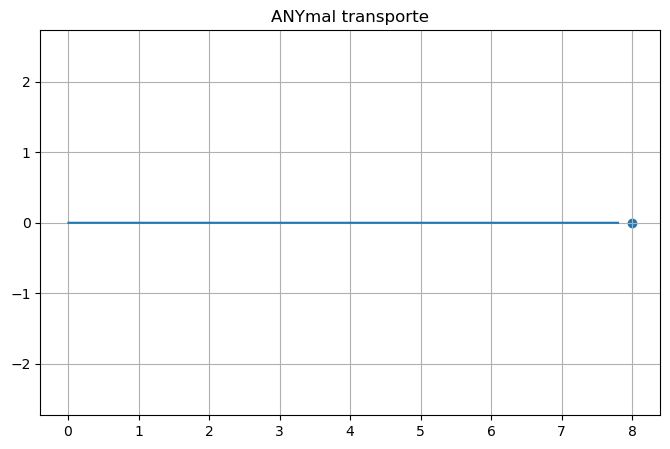

In [4]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
T = 25.0

DEST = np.array([8.0, 0.0])
TOL = 0.15

STEP_HEIGHT = 0.06
STEP_LENGTH = 0.18

BASE_SPEED = 0.6
PAYLOAD_MASS = 6.0
ROBOT_MASS = 30.0

V_FORWARD = BASE_SPEED * (ROBOT_MASS / (ROBOT_MASS + PAYLOAD_MASS))

LATERAL_OFFSET = {
    'LF':  0.10,
    'RF': -0.10,
    'LH':  0.10,
    'RH': -0.10,
}

CYCLE = 0.6

def interpolate(p0, pf, alpha):
    return (1 - alpha)*p0 + alpha*pf

def foot_trajectory(t, phase, base_height, leg_name):

    tau = (t / CYCLE + phase) % 1.0

    p_start = np.array([-STEP_LENGTH/2, LATERAL_OFFSET[leg_name], -base_height])
    p_end   = np.array([ STEP_LENGTH/2, LATERAL_OFFSET[leg_name], -base_height])

    if tau < 0.5:
        alpha = tau * 2
        p = interpolate(p_start, p_end, alpha)
        p[2] += STEP_HEIGHT * np.sin(np.pi * alpha)
    else:
        alpha = (tau - 0.5) * 2
        p = interpolate(p_end, p_start, alpha)
        p[2] += 0.01

    return p

def clamp_joint_angles(q):
    return np.clip(q, [-1.5, -1.0, -2.5], [1.5, 1.0, -0.3])

def compute_detJ(leg, q):
    J = leg.jacobian(q)
    return np.linalg.det(J)

from sklearn.linear_model import LogisticRegression

def generate_training_data(anymal, samples=400):

    X = []
    y = []

    for name in ['LF','RF','LH','RH']:

        leg = anymal.legs[name]

        for _ in range(samples):

            q = np.array([
                np.random.uniform(-1.2, 1.2),
                np.random.uniform(-1.0, 1.0),
                np.random.uniform(-2.2, -0.4)
            ])

            detJ = np.linalg.det(leg.jacobian(q))

            X.append(q)
            y.append(int(abs(detJ) > 0.002))  # 1 estable, 0 singular

    return np.array(X), np.array(y)

def anymal_controller(anymal, t, base_height, detJ_log, model):

    phases = {
        'LF': 0.0,
        'RH': 0.0,
        'RF': 0.5,
        'LH': 0.5,
    }

    q12 = np.zeros(12)

    for i, name in enumerate(['LF', 'RF', 'LH', 'RH']):
        leg = anymal.legs[name]

        p = foot_trajectory(t, phases[name], base_height, name)

        try:
            q = leg.inverse_kinematics(p)
        except:
            q = np.array([0.0, 0.4, -1.2])

        detJ = compute_detJ(leg, q)
        detJ_log[name].append(detJ)

        prediction = model.predict([q])[0]

        if prediction == 0:  # configuración inestable
            q[1] += 0.25
            q[2] -= 0.4

        if q[2] > -0.5:
            q[2] = -0.8

        q = clamp_joint_angles(q)
        q12[3*i:3*(i+1)] = q

    return q12

def simulate_anymal_transport():

    anymal = ANYmal()

    X, y = generate_training_data(anymal)

    stability_model = LogisticRegression()
    stability_model.fit(X, y)

    x, y = 0.0, 0.0
    trajectory = []

    detJ_log = {
        'LF': [],
        'RF': [],
        'LH': [],
        'RH': [],
    }

    payload_offsets = [
        np.array([-0.2, -0.2, 0.0]),
        np.array([ 0.0,  0.0, 0.0]),
        np.array([ 0.2,  0.2, 0.0]),
    ]

    payload_positions = []

    for t in np.arange(0, T, dt):

        base_height = 0.46 + 0.01*np.sin(2*np.pi*t)

        q12 = anymal_controller(anymal, t, base_height, detJ_log, stability_model)
        anymal.set_all_joint_angles(q12)

        dx = DEST[0] - x
        dy = DEST[1] - y

        dist = np.linalg.norm([dx, dy])
        theta = np.arctan2(dy, dx)

        if dist > 1.0:
            v = V_FORWARD
        elif dist > 0.3:
            v = 0.4 * dist + 0.05
        else:
            v = 0.12

        v = min(v, V_FORWARD)

        x += v * np.cos(theta) * dt
        y += v * np.sin(theta) * dt

        anymal.base_pos = np.array([x, y, base_height])
        trajectory.append([x, y])

        payload_step = []
        for offset in payload_offsets:
            px = x + offset[0]
            py = y + offset[1]
            pz = base_height + 0.15
            payload_step.append([px, py, pz])

        payload_positions.append(payload_step)

        if dist < 0.2:
            x = DEST[0]
            y = DEST[1]
            return True, np.array(trajectory)

        if dist < TOL:
            return True, np.array(trajectory)

    return False, np.array(trajectory)

if __name__ == "__main__":

    success, traj = simulate_anymal_transport()

    plt.figure(figsize=(8,5))
    plt.plot(traj[:,0], traj[:,1])
    plt.scatter(DEST[0], DEST[1])
    plt.title("ANYmal transporte")
    plt.grid()
    plt.axis("equal")
    plt.show()

## 5. Fase 3 — PuzzleBots cooperativos

Define los PuzzleBots usados para recoger y apilar cajas.

In [5]:
import numpy as np

# =========================================================================
# PUZZLEBOT (FISICA REAL DEL PROFE)
# =========================================================================

class PuzzleBot:
    def __init__(self, name, start_pos, r=0.05, L=0.19):

        self.name = name

        # Estado
        self.x = start_pos[0]
        self.y = start_pos[1]
        self.theta = 0.0

        # Parámetros físicos
        self.r = r
        self.L = L

        # 🔥 MÁS RÁPIDO
        self.v_max = 1.2
        self.omega_max = 4.0

        self.carrying = None

    def get_pose(self):
        return np.array([self.x, self.y])

    # ===============================
    # CINEMATICA
    # ===============================

    def inverse_kinematics(self, v, omega):
        v = np.clip(v, -self.v_max, self.v_max)
        omega = np.clip(omega, -self.omega_max, self.omega_max)

        wR = (2*v + omega*self.L) / (2*self.r)
        wL = (2*v - omega*self.L) / (2*self.r)

        return wR, wL

    def forward_kinematics(self, wR, wL):
        v = self.r/2 * (wR + wL)
        omega = self.r/self.L * (wR - wL)
        return v, omega

    def update(self, v_cmd, omega_cmd, dt=0.2):  # 🔥 dt mayor
        wR, wL = self.inverse_kinematics(v_cmd, omega_cmd)
        v, omega = self.forward_kinematics(wR, wL)

        self.x += v * np.cos(self.theta) * dt
        self.y += v * np.sin(self.theta) * dt
        self.theta += omega * dt
        self.theta = np.arctan2(np.sin(self.theta), np.cos(self.theta))


# =========================================================================
# CONTROLADOR (TUNEADO)
# =========================================================================

def go_to_target(bot, target):

    dx = target[0] - bot.x
    dy = target[1] - bot.y

    theta_target = np.arctan2(dy, dx)

    error_theta = theta_target - bot.theta
    error_theta = np.arctan2(np.sin(error_theta), np.cos(error_theta))

    dist = np.linalg.norm([dx, dy])

    # 🔥 MÁS AGRESIVO
    k_v = 2.5
    k_w = 6.0

    v = k_v * dist
    omega = k_w * error_theta

    v = np.clip(v, -bot.v_max, bot.v_max)
    omega = np.clip(omega, -bot.omega_max, bot.omega_max)

    # 🔥 SOLO gira si está MUY mal
    if abs(error_theta) > 1.0:
        v = 0.0

    return v, omega, dist


# =========================================================================
# COORDINADOR
# =========================================================================

class PuzzleCoordinator:

    def __init__(self, bots, boxes, stack_pos):

        self.bots = bots
        self.boxes = boxes
        self.stack_pos = stack_pos

        self.state = "ASSIGN"

    # ---------------------------------------------------------------------
    def assign_tasks(self):

        free_bots = [b for b in self.bots if b.carrying is None]
        free_boxes = [b for b in self.boxes if not b["stacked"]]

        for bot, box in zip(free_bots, free_boxes):
            bot.carrying = box
            print(f"🤖 {bot.name} asignado a caja {box['name']}")

    # ---------------------------------------------------------------------
    def step(self):

        if self.state == "ASSIGN":
            self.assign_tasks()
            self.state = "MOVE"
            return False

        for bot in self.bots:

            if bot.carrying is None:
                continue

            box = bot.carrying

            # =============================
            # IR A CAJA
            # =============================
            if not box.get("picked", False):

                target = box["pos"][:2]

                v, omega, dist = go_to_target(bot, target)
                bot.update(v, omega)

                print(f"{bot.name} → caja {box['name']} | dist={dist:.2f}")

                # 🔥 MÁS PERMISIVO
                if dist < 0.25:
                    box["picked"] = True
                    print(f"📦 {bot.name} recogió {box['name']}")

            # =============================
            # IR A STACK
            # =============================
            else:

                target = self.stack_pos[:2]

                v, omega, dist = go_to_target(bot, target)
                bot.update(v, omega)

                box["pos"][:2] = np.array([bot.x, bot.y])

                print(f"{bot.name} llevando {box['name']}")

                if dist < 0.25:
                    box["stacked"] = True
                    bot.carrying = None
                    print(f"🏗️ Caja {box['name']} apilada")

        # =============================
        # TERMINO
        # =============================
        if all(b["stacked"] for b in self.boxes):
            print("🎯 TODAS LAS CAJAS APILADAS")
            return True

        return False

## 6. Coordinador FSM

Une las tres fases en una máquina de estados: `HUSKY → ANYMAL → PUZZLEBOTS → DONE`.

In [6]:
import numpy as np

# IMPORTS CORREGIDOS


class Coordinator:
    """
    Coordinador de misión multi-robot.

    Arquitectura:
        - Máquina de estados (FSM)
        - Manejo de errores
        - Secuencia:
            HUSKY -> ANYMAL -> PUZZLEBOTS
    """

    def __init__(self):

        self.state = "HUSKY"
        self.max_retries = 2

        # ==============================
        # PUZZLEBOTS
        # ==============================
        self.bots = [
            PuzzleBot("PB1", [0.0, -0.5]),
            PuzzleBot("PB2", [0.0,  0.0]),
            PuzzleBot("PB3", [0.0,  0.5]),
        ]

        self.boxes = [
            {"name":"A", "pos":np.array([1.0, -0.5, 0.0]), "stacked":False},
            {"name":"B", "pos":np.array([1.2,  0.0, 0.0]), "stacked":False},
            {"name":"C", "pos":np.array([1.4,  0.5, 0.0]), "stacked":False},
        ]

        self.stack_pos = np.array([3.0, 0.0, 0.0])

        self.puzzle_coordinator = PuzzleCoordinator(
            self.bots,
            self.boxes,
            self.stack_pos
        )

    # =========================================================================
    # FASE 1: HUSKY
    # =========================================================================
    def run_husky(self):

        for attempt in range(self.max_retries):

            print(f"\n🔧 Intento Husky {attempt+1}")

            success = simulate_husky_mission()

            if success:
                print("✅ Corredor despejado")
                return True

            print("⚠️ Reintentando Husky...")

        return False

    # =========================================================================
    # FASE 2: ANYMAL
    # =========================================================================
    def run_anymal(self):

        for attempt in range(self.max_retries):

            print(f"\n🐕 Intento ANYmal {attempt+1}")

            success, traj = simulate_anymal_transport()

            if success:
                print("✅ ANYmal llegó a zona de trabajo")
                return True

            print("⚠️ Reintentando ANYmal...")

        return False

    # =========================================================================
    # FASE 3: PUZZLEBOTS
    # =========================================================================
    def run_puzzlebots(self):

        done = False
        step_count = 0

        while not done:

            print(f"\n--- STEP {step_count} ---")

            done = self.puzzle_coordinator.step()
            step_count += 1

            # protección
            if step_count > 15:
                print("⚠️ Timeout PuzzleBots")
                return False

        return True

    # =========================================================================
    # RUN COMPLETO (FSM)
    # =========================================================================
    def run(self):

        print("🚀 INICIANDO MISIÓN MULTI-ROBOT\n")

        # ==============================
        # FSM LOOP
        # ==============================
        while True:

            # -------- HUSKY --------
            if self.state == "HUSKY":

                print("🔧 FASE 1: Husky limpiando corredor...")

                if not self.run_husky():
                    print("❌ FALLÓ HUSKY")
                    return

                self.state = "ANYMAL"

            # -------- ANYMAL --------
            elif self.state == "ANYMAL":

                print("\n🐕 FASE 2: ANYmal transportando robots...")

                if not self.run_anymal():
                    print("❌ FALLÓ ANYMAL")
                    return

                self.state = "PUZZLEBOTS"

            # -------- PUZZLEBOTS --------
            elif self.state == "PUZZLEBOTS":

                print("\n🤖 FASE 3: PuzzleBots apilando cajas...")

                if not self.run_puzzlebots():
                    print("❌ FALLÓ PUZZLEBOTS")
                    return

                self.state = "DONE"

            # -------- FIN --------
            elif self.state == "DONE":

                print("\n🏁 MISIÓN COMPLETADA EXITOSAMENTE")
                return


# =========================================================================
# MAIN
# =========================================================================


## 7. Simulación visual integrada

Incluye funciones para graficar y animar la misión completa.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# =========================================================
# CONFIG GLOBAL
# =========================================================
dt = 0.05

CORRIDOR_X = [0, 8]   # 🔥 MÁS GRANDE (conecta con trabajo)
CORRIDOR_Y = [-1, 1]

START_ZONE = [-2, 0]
WORK_ZONE = [10, 0]

# =========================================================
# HUSKY CON LOGS
# =========================================================
def simulate_husky():

    husky = HuskyA200()
    husky.set_terrain("grass")

    boxes = [
        {"pos": np.array([2.0, 0.0]), "pushed": False},
        {"pos": np.array([4.0, 0.6]), "pushed": False},
        {"pos": np.array([6.0, -0.6]), "pushed": False},
    ]

    traj = []
    v_log = []
    omega_log = []
    box_traj = [[] for _ in boxes]

    current_box = 0

    for t in np.arange(0, 30, dt):

        if current_box >= len(boxes):
            break

        box = boxes[current_box]

        dx = box["pos"][0] - husky.x
        dy = box["pos"][1] - husky.y

        theta_target = np.arctan2(dy, dx)
        error = np.arctan2(np.sin(theta_target - husky.theta),
                           np.cos(theta_target - husky.theta))

        v = 0.7 if abs(error) < 0.3 else 0.2
        omega = 2.5 * error

        wR1, wR2, wL1, wL2 = husky.inverse_kinematics(v, omega)
        v_real, omega_real = husky.forward_kinematics(wR1, wR2, wL1, wL2)

        husky.update_pose(v_real, omega_real, dt)

        dist = np.linalg.norm(box["pos"] - np.array([husky.x, husky.y]))

        if dist < 0.35:
            box["pushed"] = True

        if box["pushed"]:
            direction = np.array([0, 1]) if box["pos"][1] >= 0 else np.array([0, -1])
            box["pos"] += direction * abs(v_real) * dt

        if not (CORRIDOR_Y[0] <= box["pos"][1] <= CORRIDOR_Y[1]):
            current_box += 1

        traj.append([husky.x, husky.y])
        v_log.append(v_real)
        omega_log.append(omega_real)

        for i, b in enumerate(boxes):
            box_traj[i].append(b["pos"].copy())

    return np.array(traj), np.array(v_log), np.array(omega_log), [np.array(b) for b in box_traj]


# =========================================================
# PUZZLEBOTS
# =========================================================
def simulate_puzzlebots():

    bots = [
        PuzzleBot("PB1", [8.5, -1.2]),
        PuzzleBot("PB2", [8.5,  0.0]),
        PuzzleBot("PB3", [8.5,  1.2]),
    ]

    boxes = [
        {"name":"A", "pos":np.array([9.5, -1.0, 0.0]), "stacked":False},
        {"name":"B", "pos":np.array([9.0,  0.8, 0.0]), "stacked":False},
        {"name":"C", "pos":np.array([10.2, 1.2, 0.0]), "stacked":False},
    ]

    stack = np.array([11.0, 0.0, 0.0])

    coord = PuzzleCoordinator(bots, boxes, stack)

    traj_bots = {b.name: [] for b in bots}
    traj_boxes = {b["name"]: [] for b in boxes}

    for _ in range(100):

        coord.step()

        for b in bots:
            traj_bots[b.name].append([b.x, b.y])

        for box in boxes:
            traj_boxes[box["name"]].append(box["pos"][:2].copy())

    return traj_bots, traj_boxes, stack


# =========================================================
# ANIMACIÓN COMPLETA PRO
# =========================================================
def animate_all():

    husky_traj, v_log, omega_log, husky_boxes = simulate_husky()
    anymal_success, anymal_traj = simulate_anymal_transport()
    pb_traj, pb_boxes, stack = simulate_puzzlebots()

    # 🔥 acelerar ANYmal solo visualmente
    anymal_traj = anymal_traj[::3]

    fig, ax = plt.subplots(figsize=(12,6))

    ax.set_xlim(-2, 12)
    ax.set_ylim(-3, 3)
    ax.grid()

    # ZONAS
    ax.add_patch(plt.Rectangle((-2,-2),2,4,fill=False,linestyle='--'))
    ax.add_patch(plt.Rectangle((0,-1),8,2,fill=False,linestyle='--'))
    ax.add_patch(plt.Rectangle((8,-2),4,4,fill=False,linestyle='--'))

    ax.text(-1.5,1.5,"INICIO")
    ax.text(3,1.3,"CORREDOR")
    ax.text(9,1.5,"TRABAJO")

    # ROBOTS
    husky_dot, = ax.plot([], [], 'ko', markersize=8, label="Husky")
    anymal_dot, = ax.plot([], [], 'bo', markersize=6, label="ANYmal")

    pb_dots = {name: ax.plot([], [], 'o')[0] for name in pb_traj}

    # CAJAS VISUALES (🔥 mejor diseño)
    husky_box_dots = [ax.plot([], [], 'o', alpha=0.5)[0] for _ in husky_boxes]
    pb_box_dots = {name: ax.plot([], [], 's')[0] for name in pb_boxes}

    stack_dot, = ax.plot(stack[0], stack[1], 'k*', markersize=12)

    ax.legend()

    total_frames = len(husky_traj) + len(anymal_traj) + len(next(iter(pb_traj.values())))

    def update(frame):

        # ---------------- HUSKY ----------------
        if frame < len(husky_traj):

            x, y = husky_traj[frame]
            husky_dot.set_data([x], [y])

            for i, b in enumerate(husky_boxes):
                if frame < len(b):
                    husky_box_dots[i].set_data([b[frame][0]], [b[frame][1]])

        # ---------------- ANYMAL ----------------
        elif frame < len(husky_traj) + len(anymal_traj):

            idx = frame - len(husky_traj)
            x, y = anymal_traj[idx]

            anymal_dot.set_data([x], [y])

            # 🔥 detener en zona de trabajo
            if x >= 8:
                anymal_dot.set_color('green')

        # ---------------- PUZZLEBOTS ----------------
        else:

            idx = frame - len(husky_traj) - len(anymal_traj)

            for name in pb_traj:
                data = np.array(pb_traj[name])
                if idx < len(data):
                    pb_dots[name].set_data([data[idx][0]], [data[idx][1]])

            for name in pb_boxes:
                data = np.array(pb_boxes[name])
                if idx < len(data):
                    pb_box_dots[name].set_data([data[idx][0]], [data[idx][1]])

        return list(pb_dots.values()) + list(pb_box_dots.values()) + husky_box_dots + [husky_dot, anymal_dot]

    ani = FuncAnimation(fig, update, frames=total_frames, interval=50, blit=True)
    plt.close(fig)

    # In Jupyter/Colab this displays the animation inline.
    try:
        display(HTML(ani.to_jshtml()))
    except Exception:
        plt.show()

    return ani


# =========================================================
# GRÁFICAS PRO
# =========================================================
def plot_all():

    husky_traj, v_log, omega_log, _ = simulate_husky()
    _, anymal_traj = simulate_anymal_transport()

    # HUSKY
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(husky_traj[:,0], husky_traj[:,1])
    plt.title("Trayectoria Husky")
    plt.axis("equal")
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(v_log, label="v")
    plt.plot(omega_log, label="omega")
    plt.legend()
    plt.title("Velocidades Husky")
    plt.grid()

    plt.show()

    # ANYMAL
    plt.figure(figsize=(6,5))
    plt.plot(anymal_traj[:,0], anymal_traj[:,1])
    plt.title("Trayectoria ANYmal")
    plt.axis("equal")
    plt.grid()
    plt.show()


# =========================================================
# MAIN
# =========================================================


## 8. Ejecutar misión completa con el coordinador

Esta celda ejecuta la misión por fases desde la FSM.

🚀 INICIANDO MISIÓN MULTI-ROBOT

🔧 FASE 1: Husky limpiando corredor...

🔧 Intento Husky 1
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[WATCHER] 0/3 cajas fuera
[

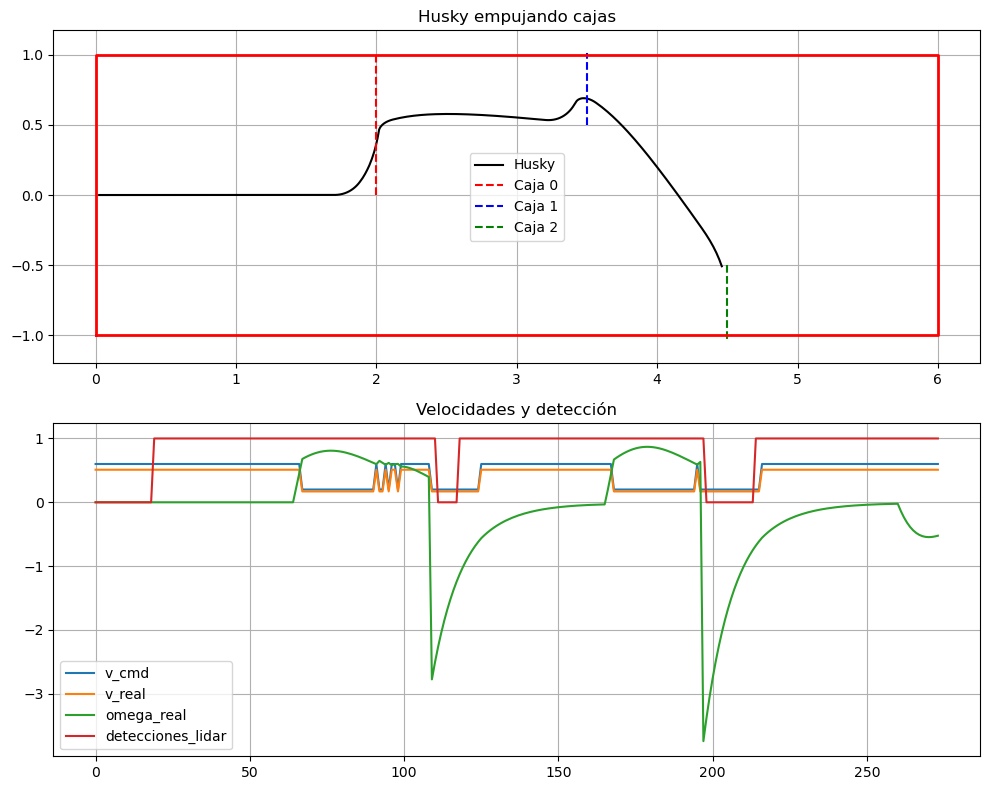

✅ Corredor despejado

🐕 FASE 2: ANYmal transportando robots...

🐕 Intento ANYmal 1
✅ ANYmal llegó a zona de trabajo

🤖 FASE 3: PuzzleBots apilando cajas...

--- STEP 0 ---
🤖 PB1 asignado a caja A
🤖 PB2 asignado a caja B
🤖 PB3 asignado a caja C

--- STEP 1 ---
PB1 → caja A | dist=1.00
PB2 → caja B | dist=1.20
PB3 → caja C | dist=1.40

--- STEP 2 ---
PB1 → caja A | dist=0.76
PB2 → caja B | dist=0.96
PB3 → caja C | dist=1.16

--- STEP 3 ---
PB1 → caja A | dist=0.52
PB2 → caja B | dist=0.72
PB3 → caja C | dist=0.92

--- STEP 4 ---
PB1 → caja A | dist=0.28
PB2 → caja B | dist=0.48
PB3 → caja C | dist=0.68

--- STEP 5 ---
PB1 → caja A | dist=0.14
📦 PB1 recogió A
PB2 → caja B | dist=0.24
📦 PB2 recogió B
PB3 → caja C | dist=0.44

--- STEP 6 ---
PB1 llevando A
PB2 llevando B
PB3 → caja C | dist=0.22
📦 PB3 recogió C

--- STEP 7 ---
PB1 llevando A
PB2 llevando B
PB3 llevando C

--- STEP 8 ---
PB1 llevando A
PB2 llevando B
PB3 llevando C

--- STEP 9 ---
PB1 llevando A
PB2 llevando B
PB3 llevando C

In [8]:
import numpy as np


class Coordinator:
    """
    Coordinador de misión multi-robot.

    Arquitectura:
        - Máquina de estados (FSM)
        - Manejo de errores
        - Secuencia:
            HUSKY -> ANYMAL -> PUZZLEBOTS
    """

    def __init__(self):

        self.state = "HUSKY"
        self.max_retries = 2

        # ==============================
        # PUZZLEBOTS
        # ==============================
        self.bots = [
            PuzzleBot("PB1", [0.0, -0.5]),
            PuzzleBot("PB2", [0.0,  0.0]),
            PuzzleBot("PB3", [0.0,  0.5]),
        ]

        self.boxes = [
            {"name":"A", "pos":np.array([1.0, -0.5, 0.0]), "stacked":False},
            {"name":"B", "pos":np.array([1.2,  0.0, 0.0]), "stacked":False},
            {"name":"C", "pos":np.array([1.4,  0.5, 0.0]), "stacked":False},
        ]

        self.stack_pos = np.array([3.0, 0.0, 0.0])

        self.puzzle_coordinator = PuzzleCoordinator(
            self.bots,
            self.boxes,
            self.stack_pos
        )

    # =========================================================================
    # FASE 1: HUSKY
    # =========================================================================
    def run_husky(self):

        for attempt in range(self.max_retries):

            print(f"\n🔧 Intento Husky {attempt+1}")

            success = simulate_husky_mission()

            if success:
                print("✅ Corredor despejado")
                return True

            print("⚠️ Reintentando Husky...")

        return False

    # =========================================================================
    # FASE 2: ANYMAL
    # =========================================================================
    def run_anymal(self):

        for attempt in range(self.max_retries):

            print(f"\n🐕 Intento ANYmal {attempt+1}")

            success, traj = simulate_anymal_transport()

            if success:
                print("✅ ANYmal llegó a zona de trabajo")
                return True

            print("⚠️ Reintentando ANYmal...")

        return False

    # =========================================================================
    # FASE 3: PUZZLEBOTS
    # =========================================================================
    def run_puzzlebots(self):

        done = False
        step_count = 0

        while not done:

            print(f"\n--- STEP {step_count} ---")

            done = self.puzzle_coordinator.step()
            step_count += 1

            # protección
            if step_count > 15:
                print("⚠️ Timeout PuzzleBots")
                return False

        return True

    # =========================================================================
    # RUN COMPLETO (FSM)
    # =========================================================================
    def run(self):

        print("🚀 INICIANDO MISIÓN MULTI-ROBOT\n")

        # ==============================
        # FSM LOOP
        # ==============================
        while True:

            # -------- HUSKY --------
            if self.state == "HUSKY":

                print("🔧 FASE 1: Husky limpiando corredor...")

                if not self.run_husky():
                    print("❌ FALLÓ HUSKY")
                    return

                self.state = "ANYMAL"

            # -------- ANYMAL --------
            elif self.state == "ANYMAL":

                print("\n🐕 FASE 2: ANYmal transportando robots...")

                if not self.run_anymal():
                    print("❌ FALLÓ ANYMAL")
                    return

                self.state = "PUZZLEBOTS"

            # -------- PUZZLEBOTS --------
            elif self.state == "PUZZLEBOTS":

                print("\n🤖 FASE 3: PuzzleBots apilando cajas...")

                if not self.run_puzzlebots():
                    print("❌ FALLÓ PUZZLEBOTS")
                    return

                self.state = "DONE"

            # -------- FIN --------
            elif self.state == "DONE":

                print("\n🏁 MISIÓN COMPLETADA EXITOSAMENTE")
                return


# =========================================================================
# MAIN
# =========================================================================
if __name__ == "__main__":

    coordinator = Coordinator()
    coordinator.run()

## 9. Gráficas rápidas

Muestra trayectoria del Husky, velocidades y trayectoria del ANYmal.

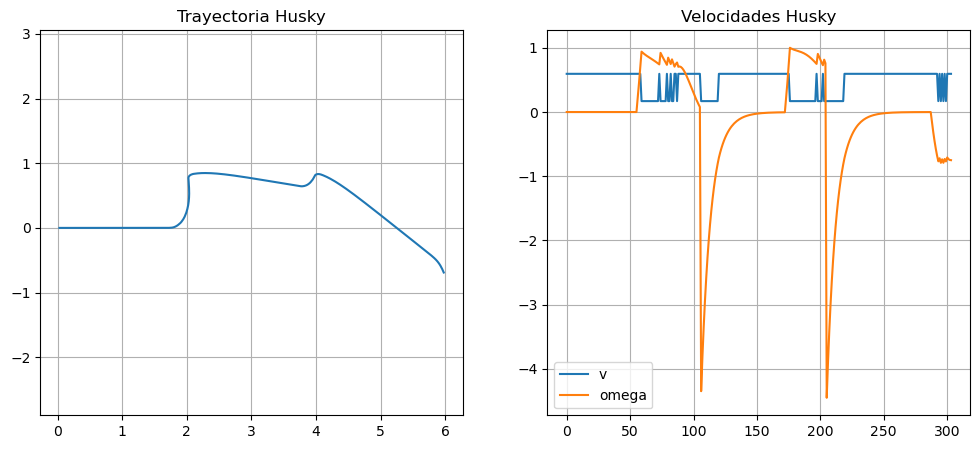

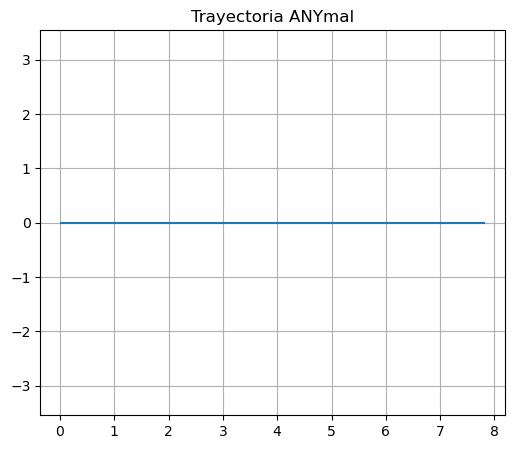

In [9]:
plot_all()


## 10. Animación completa

En Colab/Jupyter se intenta mostrar como animación HTML. Puede tardar unos segundos dependiendo del equipo.

In [10]:
ani = animate_all()


🤖 PB1 asignado a caja A
🤖 PB2 asignado a caja B
🤖 PB3 asignado a caja C
PB1 → caja A | dist=1.02
PB2 → caja B | dist=0.94
PB3 → caja C | dist=1.70
PB1 → caja A | dist=0.79
PB2 → caja B | dist=0.94
PB3 → caja C | dist=1.46
PB1 → caja A | dist=0.55
PB2 → caja B | dist=0.71
PB3 → caja C | dist=1.22
PB1 → caja A | dist=0.31
PB2 → caja B | dist=0.47
PB3 → caja C | dist=0.98
PB1 → caja A | dist=0.15
📦 PB1 recogió A
PB2 → caja B | dist=0.24
📦 PB2 recogió B
PB3 → caja C | dist=0.74
PB1 llevando A
PB2 llevando B
PB3 → caja C | dist=0.50
PB1 llevando A
PB2 llevando B
PB3 → caja C | dist=0.26
PB1 llevando A
PB2 llevando B
PB3 → caja C | dist=0.13
📦 PB3 recogió C
PB1 llevando A
PB2 llevando B
PB3 llevando C
PB1 llevando A
PB2 llevando B
PB3 llevando C
PB1 llevando A
PB2 llevando B
PB3 llevando C
PB1 llevando A
PB2 llevando B
PB3 llevando C
PB1 llevando A
🏗️ Caja A apilada
PB2 llevando B
PB3 llevando C
PB2 llevando B
PB3 llevando C
PB2 llevando B
PB3 llevando C
🏗️ Caja C apilada
PB2 llevando B
🏗️ C